## Only one circle

[Synthetic] shape: (200, 200)
[Synthetic] min/max: -0.081 / 1.540
[Circle] center x/y: 150, 115
[Circle] radius: 6 pixels
[Circle] amplitude: 1.5


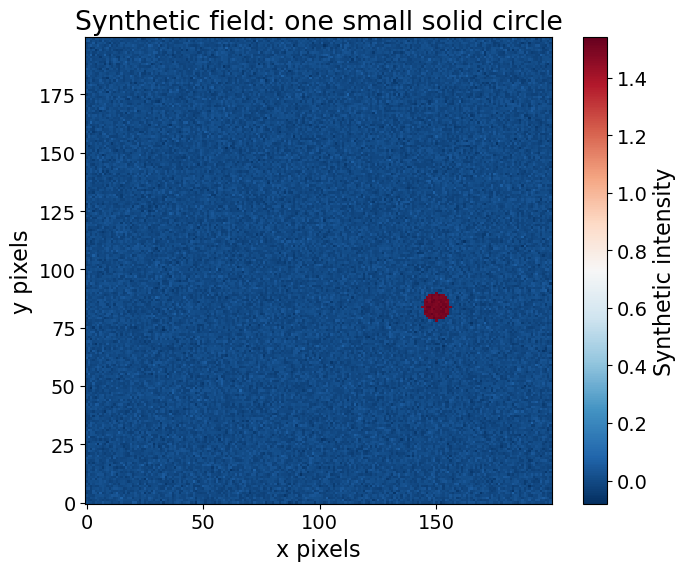

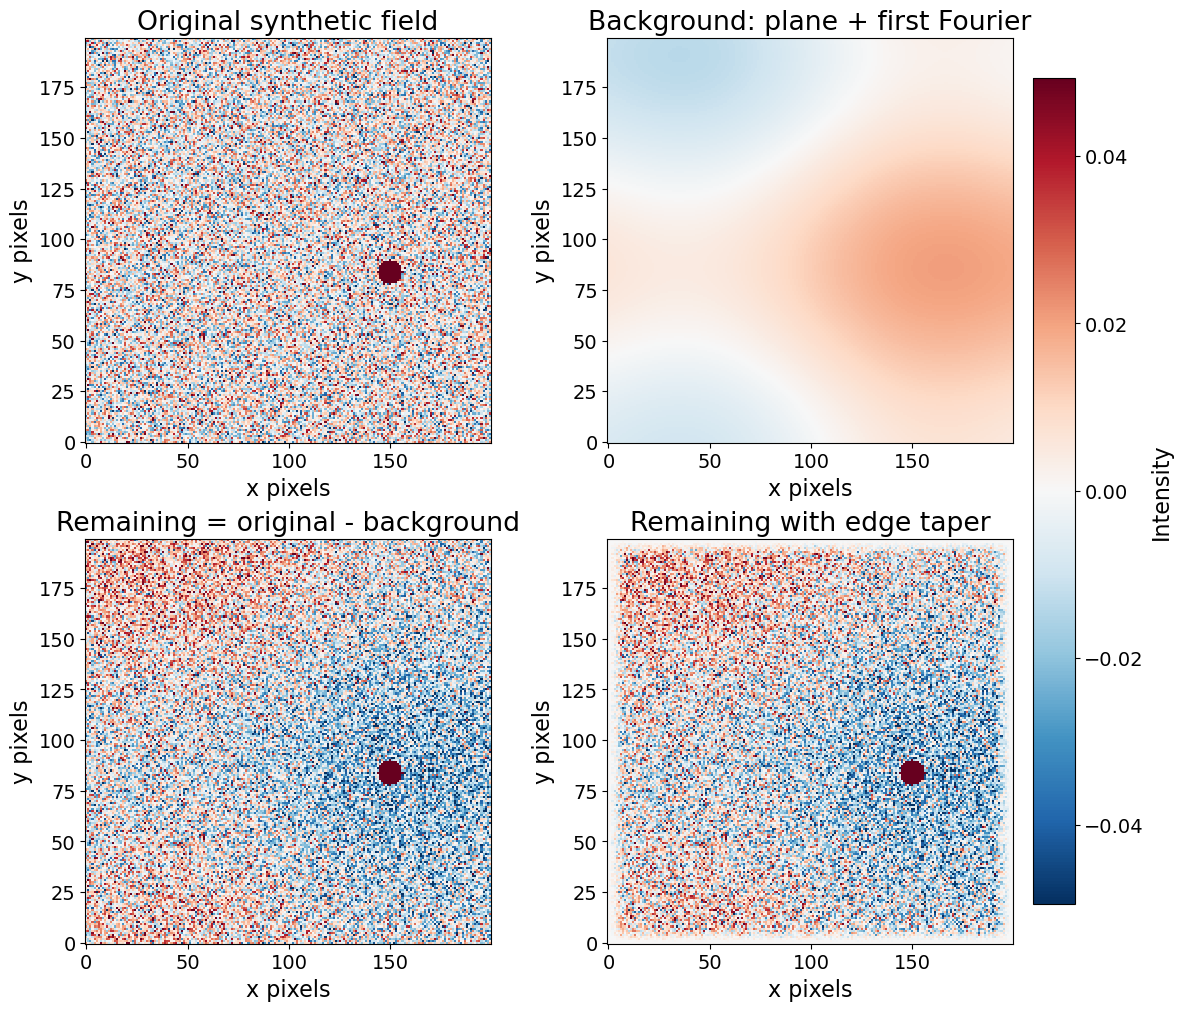

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 1.1488567611648701 idx= (np.int64(8), np.int64(14), np.int64(150), np.int64(115))
selected elements: 3256944
------------
cluster= 1
amplitude= 1.142692173368993 idx= (np.int64(8), np.int64(2), np.int64(150), np.int64(115))
selected elements: 187438
------------
cluster= 2
amplitude= 1.1374724900368707 idx= (np.int64(8), np.int64(5), np.int64(150), np.int64(115))
selected elements: 12421
------------
cluster= 3
amplitude= 0.9747228161029954 idx= (np.int64(0), np.int64(0), np.int64(147), np.int64(115))
selected elements: 3818
------------
cluster= 4
amplitude= 0.9707272297512617 idx= (np.int64(0), np.int64(9), np.int64(150), np.int64(118))
selected elements: 3880
------------
cluster= 5
amplitude= 0.5271059982864056 idx= (np.int64(2), np.int64(11), np.int64(147), np.int64(124))
selected elements: 4019
------------
cluster= 6
amplitude= 0.5250102713434693 idx= (np.int64(2), np.int64(2), np.int64(159), np.int64(118))
selected elements: 4005
------------


C:\Users\domin\juwavelet\juwavelet\utils.py:67: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 107.91it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


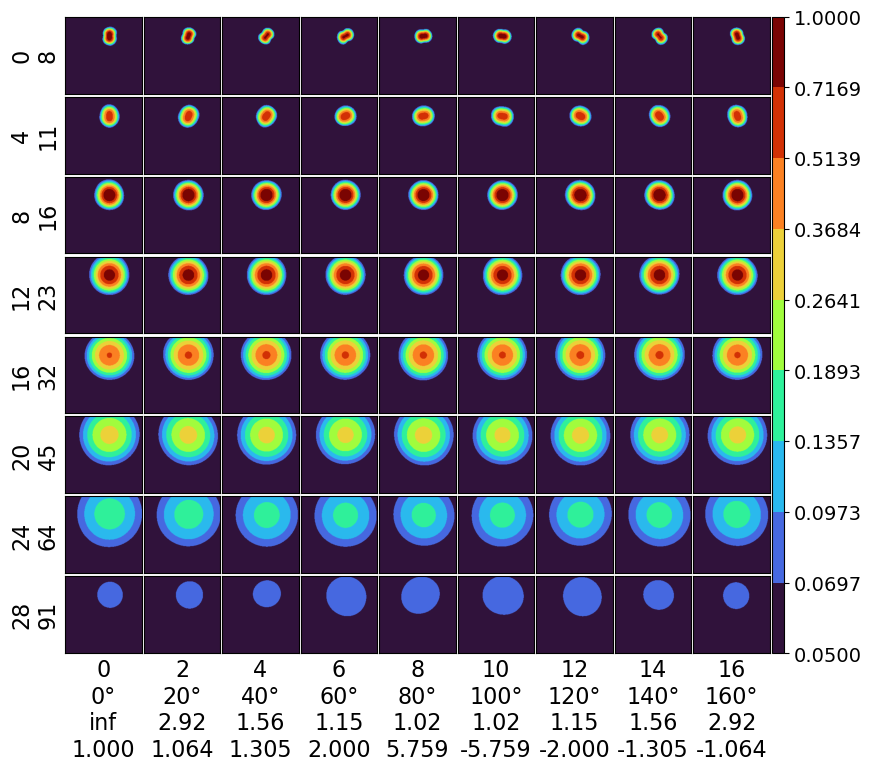

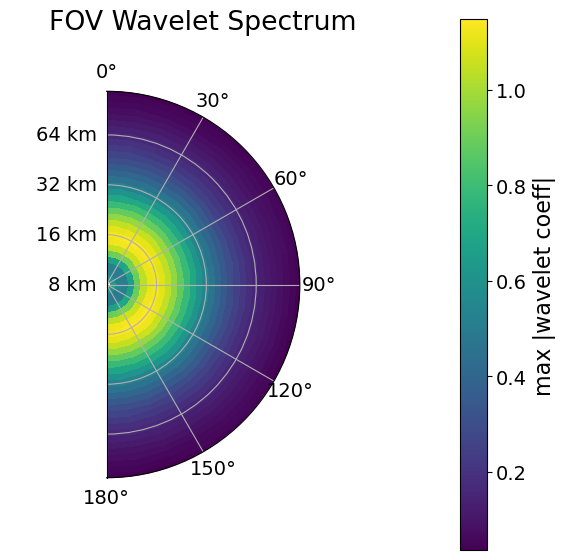

[Clusters] found: 9
[Clusters] showing: 9
[Clusters-only] Cluster 0: amp=1.149, lamx=-20.89, lamy=24.89, lam=16.00
[Clusters-only] Cluster 1: amp=1.143, lamx=17.03, lamy=46.78, lam=16.00
[Clusters-only] Cluster 2: amp=1.137, lamx=24.89, lamy=20.89, lam=16.00
[Clusters-only] Cluster 3: amp=0.975, lamx=8.00, lamy=inf, lam=8.00
[Clusters-only] Cluster 4: amp=0.971, lamx=130649914825562960.00, lamy=8.00, lam=8.00
[Clusters-only] Cluster 5: amp=0.527, lamx=-27.82, lamy=10.12, lam=9.51
[Clusters-only] Cluster 6: amp=0.525, lamx=10.12, lamy=27.82, lam=9.51
[Clusters-only] Cluster 7: amp=0.512, lamx=27.82, lamy=10.12, lam=9.51
[Clusters-only] Cluster 8: amp=0.511, lamx=-27.82, lamy=10.12, lam=9.51


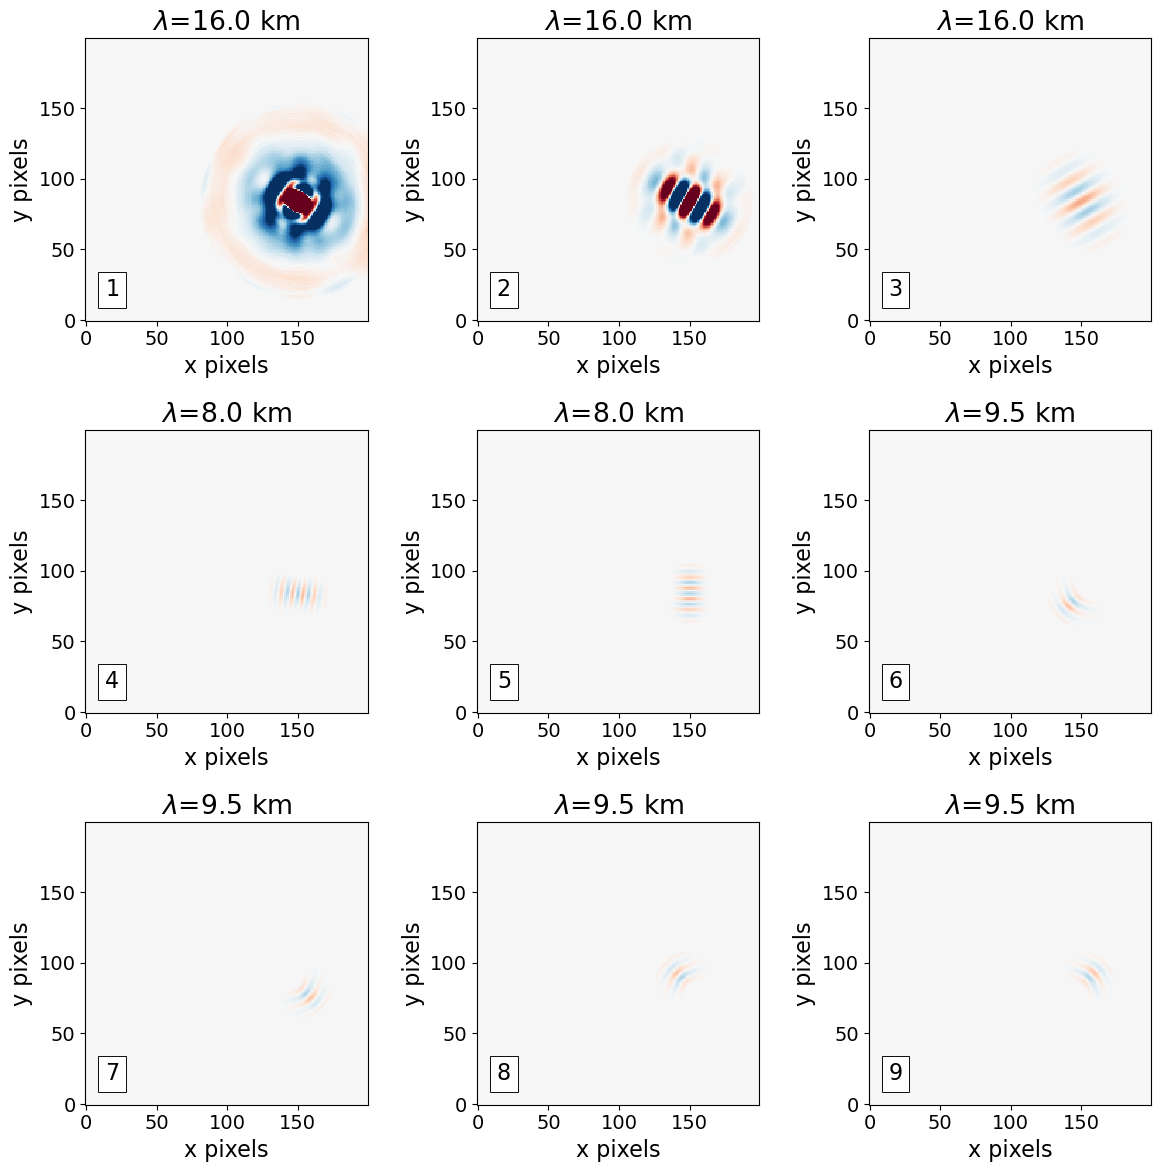

[Overlay] Cluster 0: amp=1.149, lamx=-20.89, lamy=24.89, lam=16.00
[Overlay] Cluster 1: amp=1.143, lamx=17.03, lamy=46.78, lam=16.00
[Overlay] Cluster 2: amp=1.137, lamx=24.89, lamy=20.89, lam=16.00
[Overlay] Cluster 3: amp=0.975, lamx=8.00, lamy=inf, lam=8.00
[Overlay] Cluster 4: amp=0.971, lamx=130649914825562960.00, lamy=8.00, lam=8.00
[Overlay] Cluster 5: amp=0.527, lamx=-27.82, lamy=10.12, lam=9.51
[Overlay] Cluster 6: amp=0.525, lamx=10.12, lamy=27.82, lam=9.51
[Overlay] Cluster 7: amp=0.512, lamx=27.82, lamy=10.12, lam=9.51
[Overlay] Cluster 8: amp=0.511, lamx=-27.82, lamy=10.12, lam=9.51


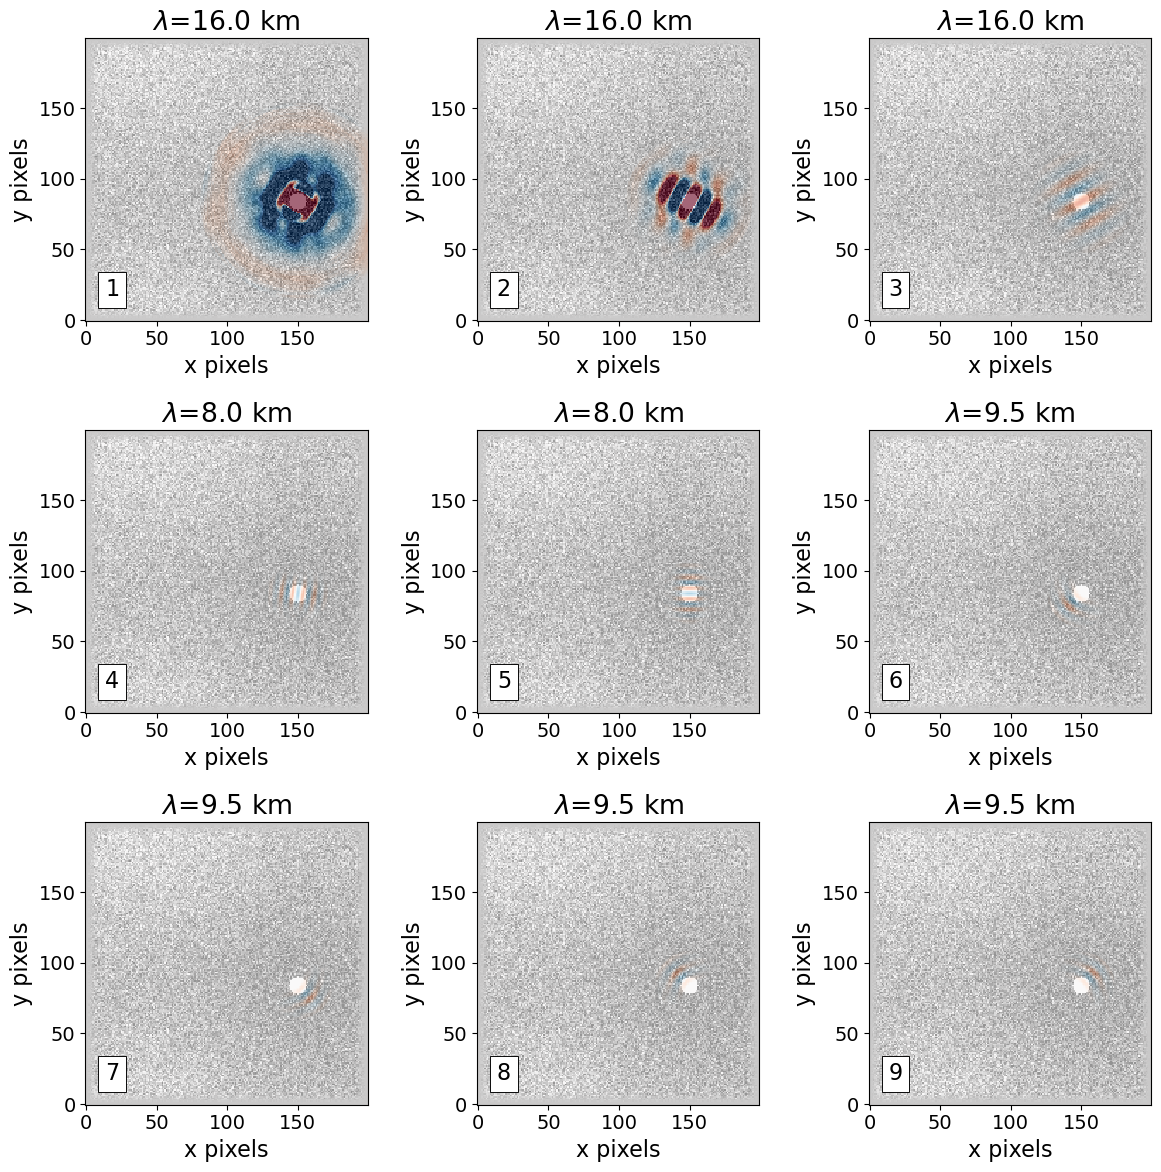

In [20]:
from __future__ import annotations
from typing import Tuple

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from scipy.ndimage import median_filter
from juwavelet import transform, utils, plot_utils


# --------------------------
# User params
# --------------------------
NX = 200
NY = 200

DX = 1
DY = 1

# Small solid circle
CIRCLE_X = 150
CIRCLE_Y = 115
CIRCLE_RADIUS = 6
CIRCLE_AMP = 1.5

# Noise
NOISE_STD = 0.02
RANDOM_SEED = 1

# Preprocessing
REMOVE_TREND = True
STANDARDIZE = True

APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10

APPLY_DESPIKE = False
DESPIKE_SIZE = 5
DESPIKE_K = 2.0

# Wavelet params
S0 = 8
DJ = 1 / 8
JS = 32
JT = 18
ASPECT = 1

# Cluster identification
CLUSTER_MIN_AMP = 0.25
CLUSTER_THR = 0.1
N_CLUSTERS_SHOW = 9


matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})


# --------------------------
# Helpers
# --------------------------
def make_synthetic_field() -> np.ndarray:
    """
    Create a synthetic 2D field containing only one small solid circle.
    """
    rng = np.random.default_rng(RANDOM_SEED)

    y, x = np.mgrid[0:NY, 0:NX]

    r = np.sqrt((x - CIRCLE_X) ** 2 + (y - CIRCLE_Y) ** 2)

    field = np.zeros((NY, NX), dtype=float)
    field[r <= CIRCLE_RADIUS] = CIRCLE_AMP

    noise = rng.normal(0, NOISE_STD, size=(NY, NX))
    field = field + noise

    return field.astype(np.float32)


def fit_plane(Z: np.ndarray) -> np.ndarray:
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = coeff[0] * xx + coeff[1] * yy + coeff[2]
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def despike_local_sigma(Z: np.ndarray, size: int = 3, k: float = 5.0) -> np.ndarray:
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad

    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]
    return Z_clean


def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    w = np.ones(n, dtype=float)

    if edge <= 0:
        return w

    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))

    w[:edge] = ramp
    w[-edge:] = ramp[::-1]

    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    ny, nx = Z.shape

    if edge <= 0:
        return Z

    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)

    W = np.outer(wy, wx)
    return Z * W


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"

    v = float(v)

    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def grid_for_nshow(n_show: int) -> Tuple[int, int]:
    if n_show == 9:
        return 3, 3
    if n_show == 6:
        return 2, 3
    if n_show == 3:
        return 1, 3
    return 1, max(n_show, 1)


# --------------------------
# Main pipeline
# --------------------------
def run_pipeline():
    raw = make_synthetic_field()

    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]

    print(f"[Synthetic] shape: {raw.shape}")
    print(f"[Synthetic] min/max: {np.nanmin(raw):.3f} / {np.nanmax(raw):.3f}")
    print(f"[Circle] center x/y: {CIRCLE_X}, {CIRCLE_Y}")
    print(f"[Circle] radius: {CIRCLE_RADIUS} pixels")
    print(f"[Circle] amplitude: {CIRCLE_AMP}")

    # --------------------------
    # Show synthetic input
    # --------------------------
    fig0, ax0 = plt.subplots(figsize=(9, 6))

    im0 = ax0.pcolormesh(
        x1d,
        y1d,
        raw,
        shading="auto",
        cmap="RdBu_r",
    )

    fig0.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04, label="Synthetic intensity")
    ax0.set_title("Synthetic field: one small solid circle")
    ax0.set_xlabel("x pixels")
    ax0.set_ylabel("y pixels")
    ax0.set_aspect("equal")

    plt.tight_layout()
    plt.show()

    # --------------------------
    # Background separation
    # --------------------------
    proc0 = raw.copy()

    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered,
            size=DESPIKE_SIZE,
            k=DESPIKE_K,
        )
    else:
        remaining_tapered_clean = remaining_tapered

    orig_c = proc0 - np.nanmedian(proc0)
    bg_c = background - np.nanmedian(proc0)
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    stacked = np.concatenate([
        orig_c.ravel(),
        bg_c.ravel(),
        rem_c.ravel(),
        rem_tapered_c.ravel(),
    ])

    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))

    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0

    vmin = -vmax

    fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    axes_bg_flat = axs_bg.flatten()

    imgs_bg = [
        (orig_c, "Original synthetic field"),
        (bg_c, "Background: plane + first Fourier"),
        (rem_c, "Remaining = original - background"),
        (rem_tapered_c, "Remaining with edge taper"),
    ]

    im_bg = None

    for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
        im_bg = ax.pcolormesh(
            x1d,
            y1d,
            Z,
            shading="auto",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(title)
        ax.set_xlabel("x pixels")
        ax.set_ylabel("y pixels")
        ax.set_aspect("equal")

    cbar_bg = fig_bg.colorbar(
        im_bg,
        ax=axs_bg,
        orientation="vertical",
        fraction=0.04,
        pad=0.02,
    )
    cbar_bg.set_label("Intensity")

    plt.show()

    # --------------------------
    # Preprocess for CWT
    # --------------------------
    proc = remaining_tapered_clean.copy()

    if STANDARDIZE:
        proc = proc - np.nanmedian(proc)
        s_proc = np.nanstd(proc)

        if s_proc > 0:
            proc = proc / s_proc

    # juwavelet expects shape: nx, ny
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy,
        dx=DX,
        dy=DY,
        s0=S0,
        dj=DJ,
        js=JS,
        jt=JT,
        aspect=ASPECT,
    )

    amps, idxs, iwave = utils.identify_cluster2d(
        cwt,
        min_amp=CLUSTER_MIN_AMP,
        thr=CLUSTER_THR,
    )

    decomposition = cwt["decomposition"]
    orig_decomp = decomposition.copy()

    # --------------------------
    # CWT summary plot
    # --------------------------
    cmap_cwt = matplotlib.cm.turbo
    norm_cwt = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)),
        cmap_cwt.N,
    )

    fig_cwt, _ = utils.plot_decomposition2d(
        cwt,
        redux_s=4,
        redux_t=2,
        cmap=cmap_cwt,
        norm=norm_cwt,
    )

    plt.show(fig_cwt)

    # --------------------------
    # FOV wavelet spectrum
    # --------------------------
    plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")

    # --------------------------
    # Cluster plots
    # --------------------------
    bg_tapered_centered = remaining_tapered_clean - np.nanmedian(remaining_tapered_clean)

    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))

    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0

    bg_vmin = -bg_vmax

    n_clusters = len(amps) if amps is not None else 0
    n_show = min(N_CLUSTERS_SHOW, n_clusters) if n_clusters > 0 else 0

    print(f"[Clusters] found: {n_clusters}")
    print(f"[Clusters] showing: {n_show}")

    number_box = {
        "boxstyle": "square",
        "lw": 0.67,
        "facecolor": "white",
        "edgecolor": "black",
    }

    nrows, ncols = grid_for_nshow(n_show)

    # --------------------------
    # Figure 1: standalone clusters
    # --------------------------
    fig1, axs1 = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes1_flat = np.atleast_1d(axs1).ravel()

    opts_img_cluster = {
        "cmap": "RdBu_r",
        "vmin": -0.8,
        "vmax": 0.8,
        "rasterized": True,
    }

    if n_show == 0:
        for ax in axes1_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        biggest = order[:n_show]

        for ax, kcl in zip(axes1_flat[:n_show], biggest):
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0

            rec = transform.reconstruct2d(cwt)
            rec_centered = rec.T - np.nanmedian(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0

            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2

            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2

            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(rf"$\lambda$={_fmt(lam)} km")

            ax.pcolormesh(
                x1d,
                y1d,
                rec_centered,
                shading="auto",
                **opts_img_cluster,
            )

            ax.set_aspect("equal", adjustable="box")

            print(
                f"[Clusters-only] Cluster {kcl}: "
                f"amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, "
                f"lamy={lamy:.2f}, "
                f"lam={lam:.2f}"
            )

        for ax in axes1_flat[n_show:]:
            ax.axis("off")

    for ax in axes1_flat[:max(n_show, 1)]:
        ax.set_xlabel("x pixels")
        ax.set_ylabel("y pixels")

    for i, ax in enumerate(axes1_flat[:n_show], start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig1.tight_layout()
    plt.show(fig1)

    # --------------------------
    # Figure 2: overlays
    # --------------------------
    fig2, axs2 = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes2_flat = np.atleast_1d(axs2).ravel()

    if n_show == 0:
        for ax in axes2_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        biggest = order[:n_show]

        cl_vmin, cl_vmax = -0.6, 0.6

        for ax, kcl in zip(axes2_flat[:n_show], biggest):
            ax.pcolormesh(
                x1d,
                y1d,
                bg_tapered_centered,
                shading="auto",
                cmap="gray",
                vmin=bg_vmin,
                vmax=bg_vmax,
            )

            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0

            rec = transform.reconstruct2d(cwt)
            rec_centered = rec.T - np.nanmedian(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0

            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2

            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2

            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.pcolormesh(
                x1d,
                y1d,
                rec_centered,
                shading="auto",
                cmap="RdBu_r",
                vmin=cl_vmin,
                vmax=cl_vmax,
                alpha=0.6,
            )

            ax.set_title(rf"$\lambda$={_fmt(lam)} km")
            ax.set_aspect("equal", adjustable="box")

            print(
                f"[Overlay] Cluster {kcl}: "
                f"amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, "
                f"lamy={lamy:.2f}, "
                f"lam={lam:.2f}"
            )

        for ax in axes2_flat[n_show:]:
            ax.axis("off")

    for ax in axes2_flat[:max(n_show, 1)]:
        ax.set_xlabel("x pixels")
        ax.set_ylabel("y pixels")

    for i, ax in enumerate(axes2_flat[:n_show], start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig2.tight_layout()
    plt.show(fig2)


if __name__ == "__main__":
    run_pipeline()

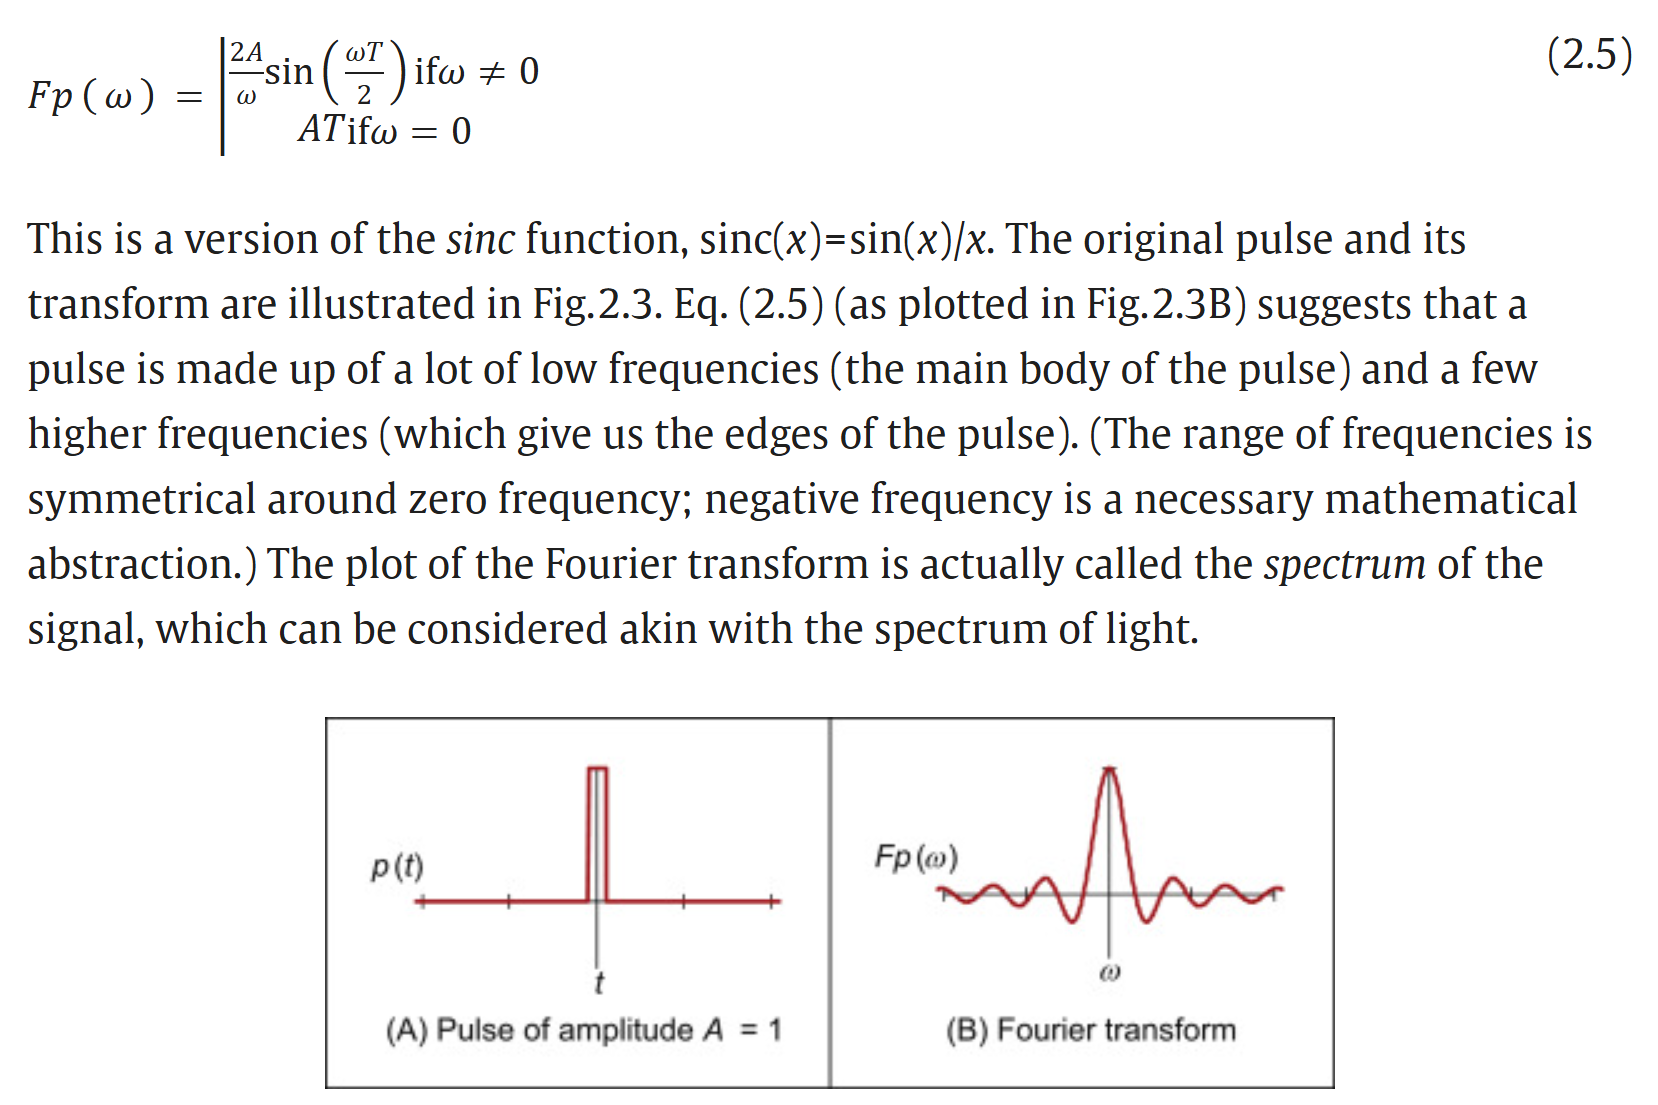

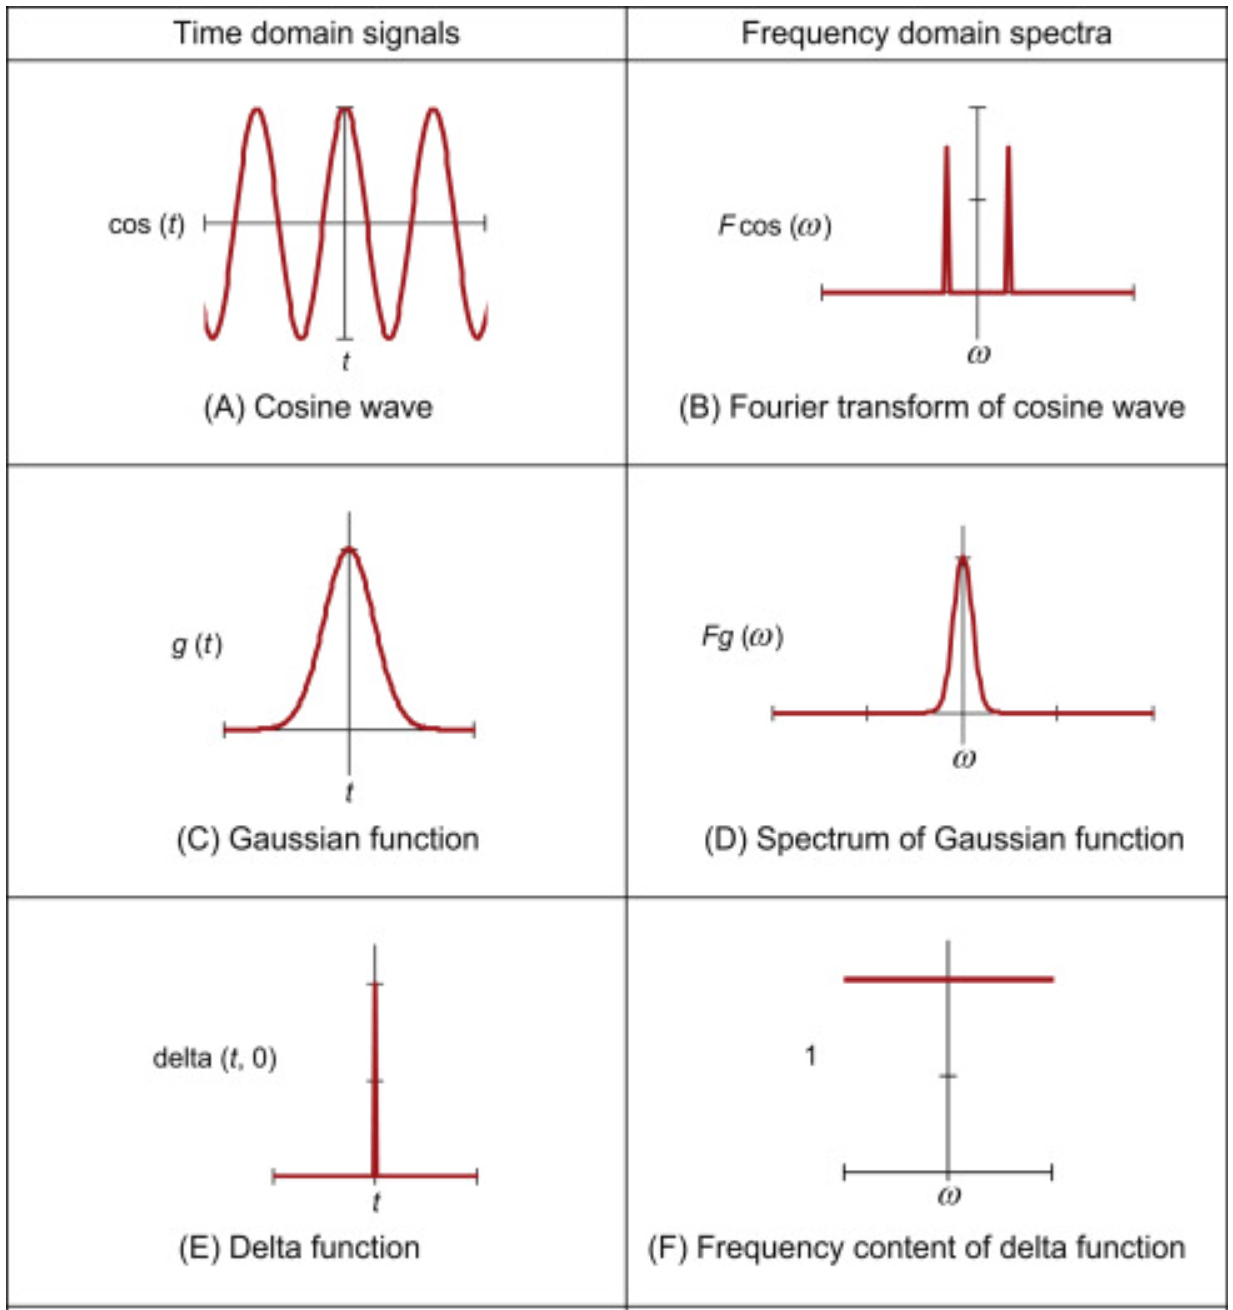

## Two wave clusters

[Synthetic] shape: (250, 250)
[Synthetic] min/max: -1.245 / 1.164

[Coordinate convention]
  No flipping
  No angle conversion
  +x = right
  +y = downward
  angles are used exactly as entered

[Truth] Cluster 1: straight
  center = (95, 115) px
  wavelength = 20.00 km
  angle = 35.00 deg
  amplitude = 1.00
  curvature = 0.0000

[Truth] Cluster 2: curved
  center = (180, 125) px
  wavelength = 34.00 km
  angle = 120.00 deg
  amplitude = 0.85
  curvature = 0.0060


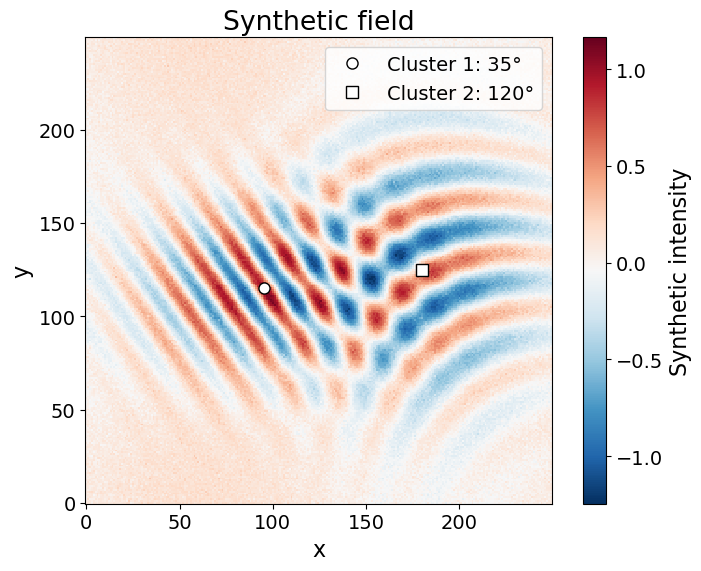

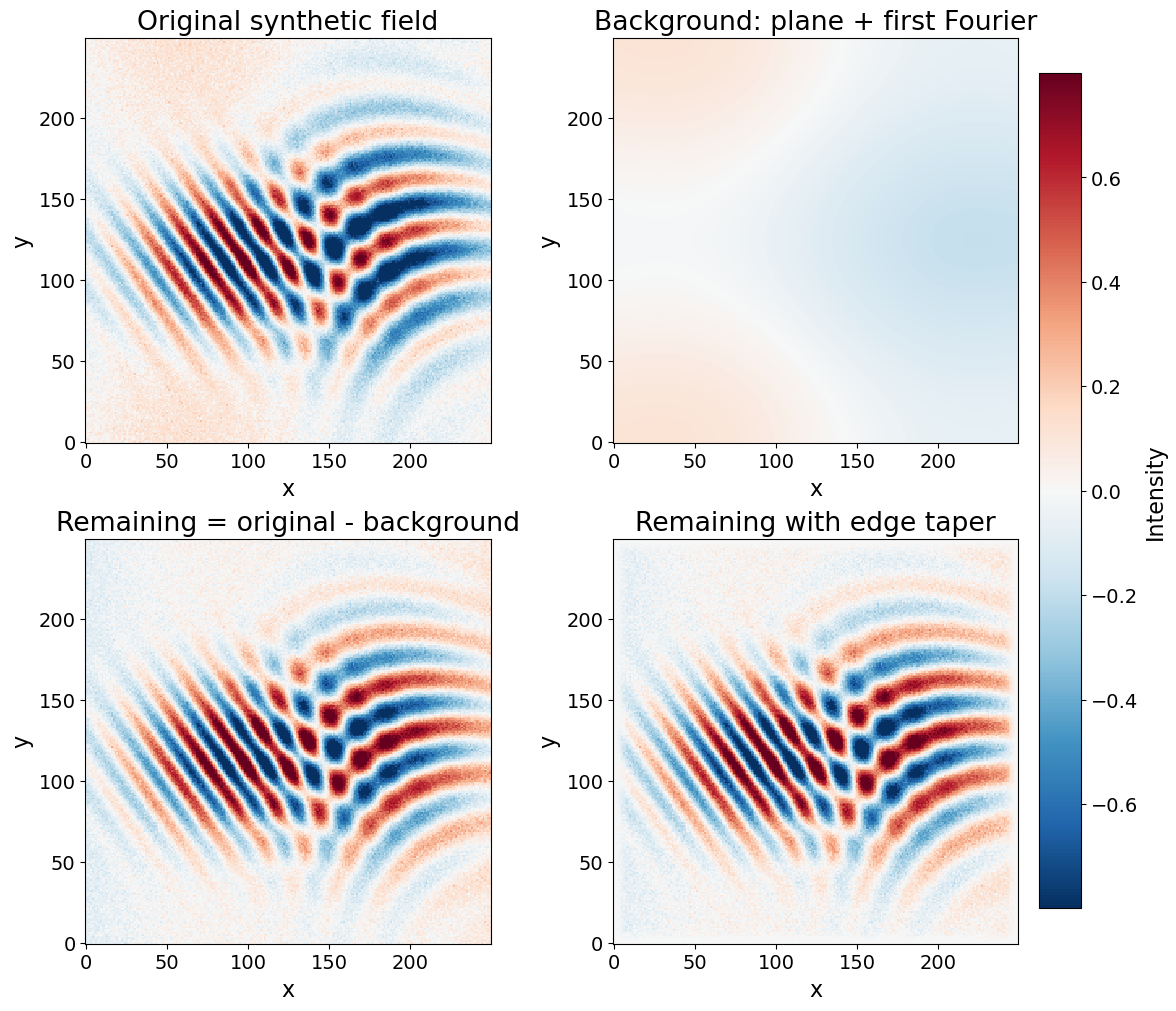

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 2.527706196799668 idx= (np.int64(10), np.int64(4), np.int64(95), np.int64(115))
selected elements: 911765
------------
cluster= 1
amplitude= 1.4815941063299094 idx= (np.int64(16), np.int64(12), np.int64(180), np.int64(125))
selected elements: 1637733
------------
cluster= 2
amplitude= 0.47856680873622387 idx= (np.int64(12), np.int64(16), np.int64(129), np.int64(86))
selected elements: 73553
------------
cluster= 3
amplitude= 0.4045177268575849 idx= (np.int64(12), np.int64(8), np.int64(221), np.int64(171))
selected elements: 60454
------------
cluster= 4
amplitude= 0.33782221341439655 idx= (np.int64(13), np.int64(7), np.int64(229), np.int64(166))
selected elements: 35669
------------
cluster= 5
amplitude= 0.3375232369330103 idx= (np.int64(13), np.int64(17), np.int64(123), np.int64(81))
selected elements: 41835


C:\Users\domin\juwavelet\juwavelet\utils.py:67: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 98.05it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


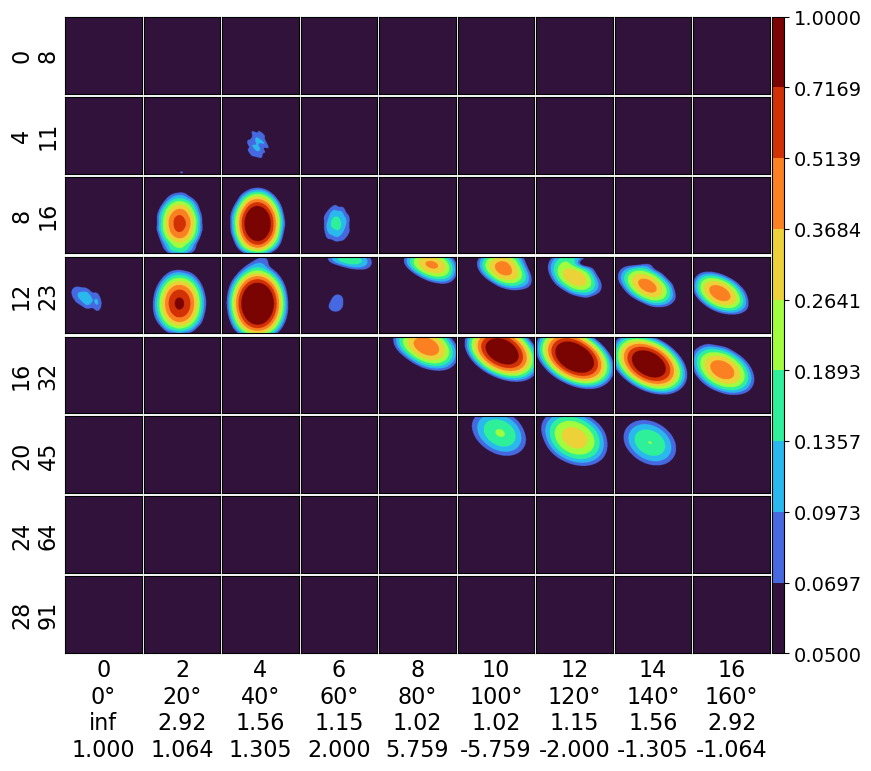

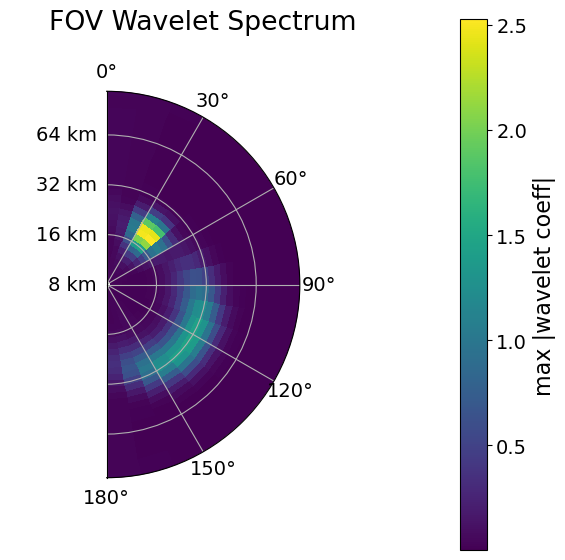


[Clusters] found: 6
[Clusters] showing: 6
[Clusters-only] Cluster 0: amp=2.528, lamx=24.84, lamy=29.60, lam=19.03
[Clusters-only] Cluster 1: amp=1.482, lamx=-64.00, lamy=36.95, lam=32.00
[Clusters-only] Cluster 2: amp=0.479, lamx=-24.08, lamy=66.16, lam=22.63
[Clusters-only] Cluster 3: amp=0.405, lamx=130.31, lamy=22.98, lam=22.63
[Clusters-only] Cluster 4: amp=0.338, lamx=72.15, lamy=26.26, lam=24.68
[Clusters-only] Cluster 5: amp=0.338, lamx=-25.06, lamy=142.10, lam=24.68


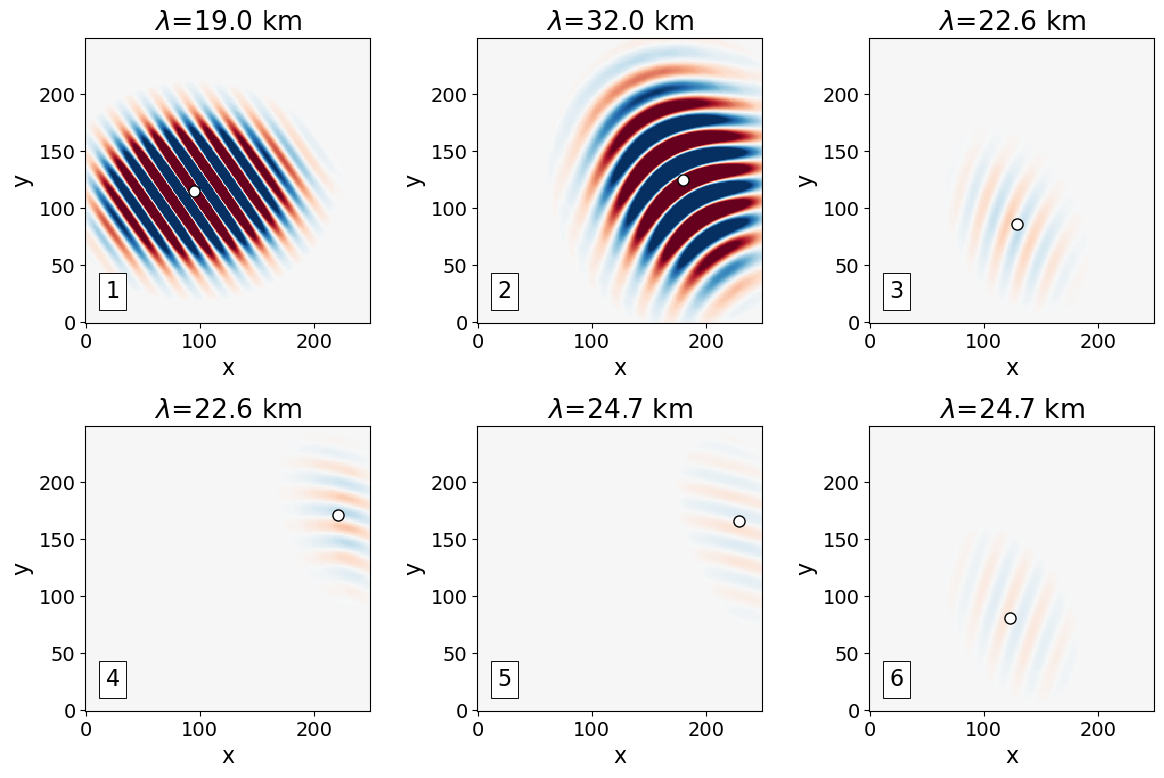

[Overlay] Cluster 0: amp=2.528, lamx=24.84, lamy=29.60, lam=19.03
[Overlay] Cluster 1: amp=1.482, lamx=-64.00, lamy=36.95, lam=32.00
[Overlay] Cluster 2: amp=0.479, lamx=-24.08, lamy=66.16, lam=22.63
[Overlay] Cluster 3: amp=0.405, lamx=130.31, lamy=22.98, lam=22.63
[Overlay] Cluster 4: amp=0.338, lamx=72.15, lamy=26.26, lam=24.68
[Overlay] Cluster 5: amp=0.338, lamx=-25.06, lamy=142.10, lam=24.68


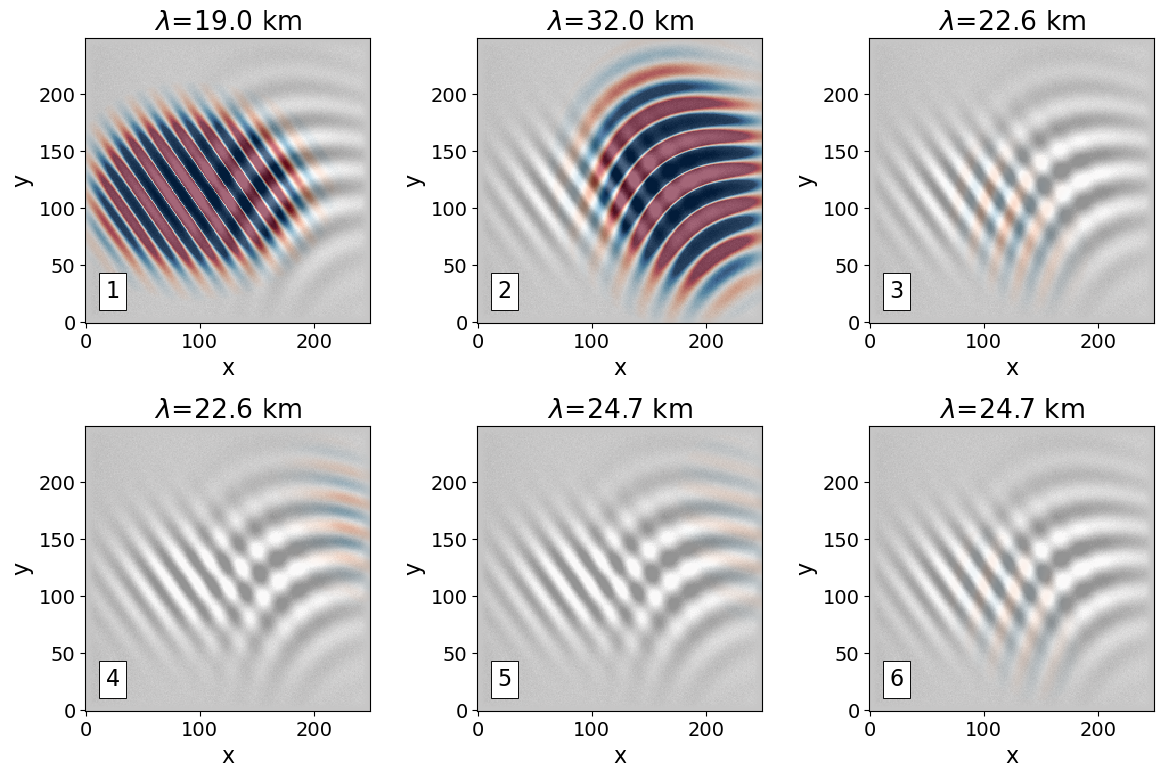

In [18]:
from __future__ import annotations
from typing import Tuple

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from scipy.ndimage import median_filter
from juwavelet import transform, utils, plot_utils


# --------------------------
# User params
# --------------------------
NX = 250
NY = 250

DX = 1
DY = 1

# No flipping. No angle conversion.
# Image-coordinate convention:
#   +x = right
#   +y = downward
#   angle is used exactly as entered
USE_CARTESIAN_COORDS = False
FLIP_DISPLAY_ANGLE = False

# --------------------------
# Synthetic wave cluster 1: straight
# --------------------------
CLUSTER1_X0 = 95
CLUSTER1_Y0 = 115
CLUSTER1_SIGMA_X = 45
CLUSTER1_SIGMA_Y = 32
CLUSTER1_AMP = 1.0
CLUSTER1_LAMBDA_KM = 20.0
CLUSTER1_ANGLE_DEG = 35.0
CLUSTER1_PHASE = 0.0
CLUSTER1_CURVATURE = 0.0

# --------------------------
# Synthetic wave cluster 2: curved
# --------------------------
CLUSTER2_X0 = 180
CLUSTER2_Y0 = 125
CLUSTER2_SIGMA_X = 42
CLUSTER2_SIGMA_Y = 48
CLUSTER2_AMP = 0.85
CLUSTER2_LAMBDA_KM = 34.0
CLUSTER2_ANGLE_DEG = 120.0
CLUSTER2_PHASE = 0.7
CLUSTER2_CURVATURE = 0.006

# Noise
NOISE_STD = 0.04
RANDOM_SEED = 1

# Optional weak large-scale background
ADD_BACKGROUND = True
BACKGROUND_AMP = 0.15

# Preprocessing
REMOVE_TREND = True
STANDARDIZE = True

APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10

APPLY_DESPIKE = False
DESPIKE_SIZE = 5
DESPIKE_K = 2.0

# Wavelet params
S0 = 8
DJ = 1 / 8
JS = 32
JT = 18
ASPECT = 1

# Cluster identification
CLUSTER_MIN_AMP = 0.25
CLUSTER_THR = 0.1
N_CLUSTERS_SHOW = 9


matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})


# --------------------------
# Helpers
# --------------------------
def make_coordinate_grids() -> Tuple[np.ndarray, np.ndarray]:
    """
    Return x, y grids using image-coordinate convention.

    No flipping:
        x increases to the right
        y increases downward
    """
    y, x = np.mgrid[0:NY, 0:NX]

    return x.astype(float), y.astype(float)


def make_gaussian_wave_cluster(
    x: np.ndarray,
    y: np.ndarray,
    x0: float,
    y0: float,
    sigma_x: float,
    sigma_y: float,
    amp: float,
    wavelength_km: float,
    angle_deg: float,
    phase: float = 0.0,
    curvature: float = 0.0,
) -> np.ndarray:
    """
    Create one localized Gaussian wave packet.

    No angle conversion:
        angle_deg is used exactly as entered.

    With image coordinates:
        +x = right
        +y = downward
    """
    theta = np.deg2rad(angle_deg)

    lambda_pix = wavelength_km / DX
    k_pix = 2.0 * np.pi / lambda_pix

    x_rel = x - x0
    y_rel = y - y0

    # Coordinate along wave-normal/propagation direction
    s = x_rel * np.cos(theta) + y_rel * np.sin(theta)

    # Coordinate perpendicular to wave-normal direction
    q = -x_rel * np.sin(theta) + y_rel * np.cos(theta)

    # Quadratic phase shift curves the wave crests
    s_curved = s + curvature * q**2

    envelope = np.exp(
        -0.5 * (
            (x_rel / sigma_x) ** 2
            + (y_rel / sigma_y) ** 2
        )
    )

    wave = amp * envelope * np.cos(k_pix * s_curved + phase)

    return wave


def make_synthetic_field() -> np.ndarray:
    """
    Create a synthetic 2D field with:
      - Cluster 1: straight Gaussian wave packet
      - Cluster 2: curved Gaussian wave packet
    """
    rng = np.random.default_rng(RANDOM_SEED)

    x, y = make_coordinate_grids()

    cluster1 = make_gaussian_wave_cluster(
        x=x,
        y=y,
        x0=CLUSTER1_X0,
        y0=CLUSTER1_Y0,
        sigma_x=CLUSTER1_SIGMA_X,
        sigma_y=CLUSTER1_SIGMA_Y,
        amp=CLUSTER1_AMP,
        wavelength_km=CLUSTER1_LAMBDA_KM,
        angle_deg=CLUSTER1_ANGLE_DEG,
        phase=CLUSTER1_PHASE,
        curvature=CLUSTER1_CURVATURE,
    )

    cluster2 = make_gaussian_wave_cluster(
        x=x,
        y=y,
        x0=CLUSTER2_X0,
        y0=CLUSTER2_Y0,
        sigma_x=CLUSTER2_SIGMA_X,
        sigma_y=CLUSTER2_SIGMA_Y,
        amp=CLUSTER2_AMP,
        wavelength_km=CLUSTER2_LAMBDA_KM,
        angle_deg=CLUSTER2_ANGLE_DEG,
        phase=CLUSTER2_PHASE,
        curvature=CLUSTER2_CURVATURE,
    )

    if ADD_BACKGROUND:
        background = BACKGROUND_AMP * (
            0.6 * np.sin(2.0 * np.pi * x / NX)
            + 0.4 * np.cos(2.0 * np.pi * y / NY)
        )
    else:
        background = 0.0

    noise = rng.normal(0.0, NOISE_STD, size=(NY, NX))

    field = cluster1 + cluster2 + background + noise

    return field.astype(np.float32)


def fit_plane(Z: np.ndarray) -> np.ndarray:
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]

    G = np.stack(
        [xx.ravel(), yy.ravel(), np.ones(nx * ny)],
        axis=1,
    )

    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)

    plane = coeff[0] * xx + coeff[1] * yy + coeff[2]

    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Keep only first Fourier components:
      kx = ±1, ky = 0
      ky = ±1, kx = 0
    """
    ny, nx = Z.shape

    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg

    return bg, resid


def despike_local_sigma(
    Z: np.ndarray,
    size: int = 3,
    k: float = 5.0,
) -> np.ndarray:
    Z = np.asarray(Z, float)

    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad

    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]

    return Z_clean


def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    w = np.ones(n, dtype=float)

    if edge <= 0:
        return w

    edge = min(edge, n // 2)

    ramp = 0.5 * (
        1.0 - np.cos(np.linspace(0.0, np.pi, edge, endpoint=True))
    )

    w[:edge] = ramp
    w[-edge:] = ramp[::-1]

    return w


def apply_edge_hanning_taper(
    Z: np.ndarray,
    edge: int,
) -> np.ndarray:
    ny, nx = Z.shape

    if edge <= 0:
        return Z

    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)

    W = np.outer(wy, wx)

    return Z * W


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"

    v = float(v)

    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"

    if abs(v) >= 100:
        return f"{v:.0f}"

    return f"{v:.1f}"


def grid_for_nshow(n_show: int) -> Tuple[int, int]:
    if n_show == 9:
        return 3, 3

    if n_show == 6:
        return 2, 3

    if n_show == 3:
        return 1, 3

    return 1, max(n_show, 1)


def harmonic_wavelength_km(
    cwt: dict,
    s_idx: int,
    t_idx: int,
) -> float:
    lamx = cwt["wavelength_x"][s_idx, t_idx]
    lamy = cwt["wavelength_y"][s_idx, t_idx]

    inv2 = 0.0

    if np.isfinite(lamx) and lamx != 0:
        inv2 += (1.0 / lamx) ** 2

    if np.isfinite(lamy) and lamy != 0:
        inv2 += (1.0 / lamy) ** 2

    if inv2 == 0:
        return np.inf

    return 1.0 / np.sqrt(inv2)


# --------------------------
# Main pipeline
# --------------------------
def run_pipeline():
    raw = make_synthetic_field()

    ny, nx = raw.shape

    # No display flip
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)

    print(f"[Synthetic] shape: {raw.shape}")
    print(f"[Synthetic] min/max: {np.nanmin(raw):.3f} / {np.nanmax(raw):.3f}")

    print("")
    print("[Coordinate convention]")
    print("  No flipping")
    print("  No angle conversion")
    print("  +x = right")
    print("  +y = downward")
    print("  angles are used exactly as entered")

    print("")
    print("[Truth] Cluster 1: straight")
    print(f"  center = ({CLUSTER1_X0}, {CLUSTER1_Y0}) px")
    print(f"  wavelength = {CLUSTER1_LAMBDA_KM:.2f} km")
    print(f"  angle = {CLUSTER1_ANGLE_DEG:.2f} deg")
    print(f"  amplitude = {CLUSTER1_AMP:.2f}")
    print(f"  curvature = {CLUSTER1_CURVATURE:.4f}")

    print("")
    print("[Truth] Cluster 2: curved")
    print(f"  center = ({CLUSTER2_X0}, {CLUSTER2_Y0}) px")
    print(f"  wavelength = {CLUSTER2_LAMBDA_KM:.2f} km")
    print(f"  angle = {CLUSTER2_ANGLE_DEG:.2f} deg")
    print(f"  amplitude = {CLUSTER2_AMP:.2f}")
    print(f"  curvature = {CLUSTER2_CURVATURE:.4f}")

    # --------------------------
    # Show synthetic input
    # --------------------------
    fig0, ax0 = plt.subplots(figsize=(9, 6))

    im0 = ax0.pcolormesh(
        x1d,
        y1d,
        raw,
        shading="auto",
        cmap="RdBu_r",
    )

    fig0.colorbar(
        im0,
        ax=ax0,
        fraction=0.046,
        pad=0.04,
        label="Synthetic intensity",
    )

    ax0.plot(
        CLUSTER1_X0,
        CLUSTER1_Y0,
        "wo",
        markeredgecolor="k",
        markersize=8,
        label=f"Cluster 1: {CLUSTER1_ANGLE_DEG:.0f}°",
    )

    ax0.plot(
        CLUSTER2_X0,
        CLUSTER2_Y0,
        "ws",
        markeredgecolor="k",
        markersize=8,
        label=f"Cluster 2: {CLUSTER2_ANGLE_DEG:.0f}°",
    )

    ax0.set_title("Synthetic field")
    ax0.set_xlabel("x")
    ax0.set_ylabel("y")
    ax0.set_aspect("equal")
    ax0.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

    # --------------------------
    # Background separation
    # --------------------------
    proc0 = raw.copy()

    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)

    background = plane + fourier_bg
    remaining = proc0 - background

    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(
            remaining,
            TAPER_EDGE_PIXELS,
        )
    else:
        remaining_tapered = remaining.copy()

    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered,
            size=DESPIKE_SIZE,
            k=DESPIKE_K,
        )
    else:
        remaining_tapered_clean = remaining_tapered

    orig_c = proc0 - np.nanmedian(proc0)
    bg_c = background - np.nanmedian(proc0)
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    stacked = np.concatenate(
        [
            orig_c.ravel(),
            bg_c.ravel(),
            rem_c.ravel(),
            rem_tapered_c.ravel(),
        ]
    )

    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))

    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0

    vmin = -vmax

    fig_bg, axs_bg = plt.subplots(
        2,
        2,
        figsize=(12, 10),
        constrained_layout=True,
    )

    axes_bg_flat = axs_bg.flatten()

    imgs_bg = [
        (orig_c, "Original synthetic field"),
        (bg_c, "Background: plane + first Fourier"),
        (rem_c, "Remaining = original - background"),
        (rem_tapered_c, "Remaining with edge taper"),
    ]

    im_bg = None

    for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
        im_bg = ax.pcolormesh(
            x1d,
            y1d,
            Z,
            shading="auto",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_aspect("equal")

    cbar_bg = fig_bg.colorbar(
        im_bg,
        ax=axs_bg,
        orientation="vertical",
        fraction=0.04,
        pad=0.02,
    )

    cbar_bg.set_label("Intensity")

    plt.show()

    # --------------------------
    # Preprocess for CWT
    # --------------------------
    proc = remaining_tapered_clean.copy()

    if STANDARDIZE:
        proc = proc - np.nanmedian(proc)
        s_proc = np.nanstd(proc)

        if s_proc > 0:
            proc = proc / s_proc

    # juwavelet expects shape: nx, ny
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy,
        dx=DX,
        dy=DY,
        s0=S0,
        dj=DJ,
        js=JS,
        jt=JT,
        aspect=ASPECT,
    )

    amps, idxs, iwave = utils.identify_cluster2d(
        cwt,
        min_amp=CLUSTER_MIN_AMP,
        thr=CLUSTER_THR,
    )

    decomposition = cwt["decomposition"]
    orig_decomp = decomposition.copy()

    # --------------------------
    # CWT summary
    # --------------------------
    cmap_cwt = matplotlib.cm.turbo

    norm_cwt = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)),
        cmap_cwt.N,
    )

    fig_cwt, _ = utils.plot_decomposition2d(
        cwt,
        redux_s=4,
        redux_t=2,
        cmap=cmap_cwt,
        norm=norm_cwt,
    )

    plt.show(fig_cwt)

    # --------------------------
    # FOV wavelet spectrum
    # --------------------------
    plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")

    # --------------------------
    # Cluster plots
    # --------------------------
    bg_tapered_centered = (
        remaining_tapered_clean - np.nanmedian(remaining_tapered_clean)
    )

    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))

    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0

    bg_vmin = -bg_vmax

    n_clusters = len(amps) if amps is not None else 0
    n_show = min(N_CLUSTERS_SHOW, n_clusters) if n_clusters > 0 else 0

    print("")
    print(f"[Clusters] found: {n_clusters}")
    print(f"[Clusters] showing: {n_show}")

    number_box = {
        "boxstyle": "square",
        "lw": 0.67,
        "facecolor": "white",
        "edgecolor": "black",
    }

    nrows, ncols = grid_for_nshow(n_show)

    # --------------------------
    # Figure 1: standalone clusters
    # --------------------------
    fig1, axs1 = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 4 * nrows),
    )

    axes1_flat = np.atleast_1d(axs1).ravel()

    opts_img_cluster = {
        "cmap": "RdBu_r",
        "vmin": -0.8,
        "vmax": 0.8,
        "rasterized": True,
    }

    if n_show == 0:
        for ax in axes1_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        biggest = order[:n_show]

        for ax, kcl in zip(axes1_flat[:n_show], biggest):
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0

            rec = transform.reconstruct2d(cwt)
            rec_centered = rec.T - np.nanmedian(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]
            lam = harmonic_wavelength_km(cwt, s_idx, t_idx)

            ax.set_title(rf"$\lambda$={_fmt(lam)} km")

            ax.pcolormesh(
                x1d,
                y1d,
                rec_centered,
                shading="auto",
                **opts_img_cluster,
            )

            ax.set_aspect("equal", adjustable="box")

            decomposition_abs = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition_abs[s_idx, t_idx].argmax(),
                decomposition_abs[0, 0].shape,
            )

            ax.plot(
                x1d[max_idx[0]],
                y1d[max_idx[1]],
                "o",
                color="w",
                mec="k",
                ms=8,
            )

            print(
                f"[Clusters-only] Cluster {kcl}: "
                f"amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, "
                f"lamy={lamy:.2f}, "
                f"lam={lam:.2f}"
            )

        for ax in axes1_flat[n_show:]:
            ax.axis("off")

    for ax in axes1_flat[:max(n_show, 1)]:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    for i, ax in enumerate(axes1_flat[:n_show], start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig1.tight_layout()
    plt.show(fig1)

    # --------------------------
    # Figure 2: overlays
    # --------------------------
    fig2, axs2 = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 4 * nrows),
    )

    axes2_flat = np.atleast_1d(axs2).ravel()

    if n_show == 0:
        for ax in axes2_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        biggest = order[:n_show]

        cl_vmin, cl_vmax = -0.6, 0.6

        for ax, kcl in zip(axes2_flat[:n_show], biggest):
            ax.pcolormesh(
                x1d,
                y1d,
                bg_tapered_centered,
                shading="auto",
                cmap="gray",
                vmin=bg_vmin,
                vmax=bg_vmax,
            )

            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0

            rec = transform.reconstruct2d(cwt)
            rec_centered = rec.T - np.nanmedian(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]
            lam = harmonic_wavelength_km(cwt, s_idx, t_idx)

            ax.pcolormesh(
                x1d,
                y1d,
                rec_centered,
                shading="auto",
                cmap="RdBu_r",
                vmin=cl_vmin,
                vmax=cl_vmax,
                alpha=0.6,
            )

            ax.set_title(rf"$\lambda$={_fmt(lam)} km")
            ax.set_aspect("equal", adjustable="box")

            print(
                f"[Overlay] Cluster {kcl}: "
                f"amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, "
                f"lamy={lamy:.2f}, "
                f"lam={lam:.2f}"
            )

        for ax in axes2_flat[n_show:]:
            ax.axis("off")

    for ax in axes2_flat[:max(n_show, 1)]:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    for i, ax in enumerate(axes2_flat[:n_show], start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig2.tight_layout()
    plt.show(fig2)


if __name__ == "__main__":
    run_pipeline()

## Bigger wavelength

[Synthetic] shape: (250, 250)
[Synthetic] min/max: 0.178 / 1.071

[Coordinate convention]
  No flipping
  No angle conversion
  +x = right
  +y = downward
  angles are used exactly as entered

[Truth] One long wave
  center = (125.0, 125.0) px
  FOV = 250.0 km × 250.0 km
  wavelength = 800.00 km
  angle = 35.00 deg
  amplitude = 1.00
  curvature = 0.0000


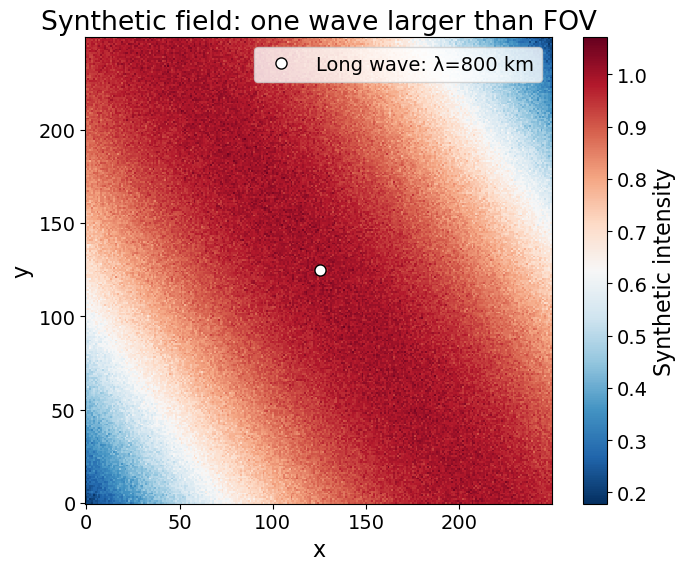

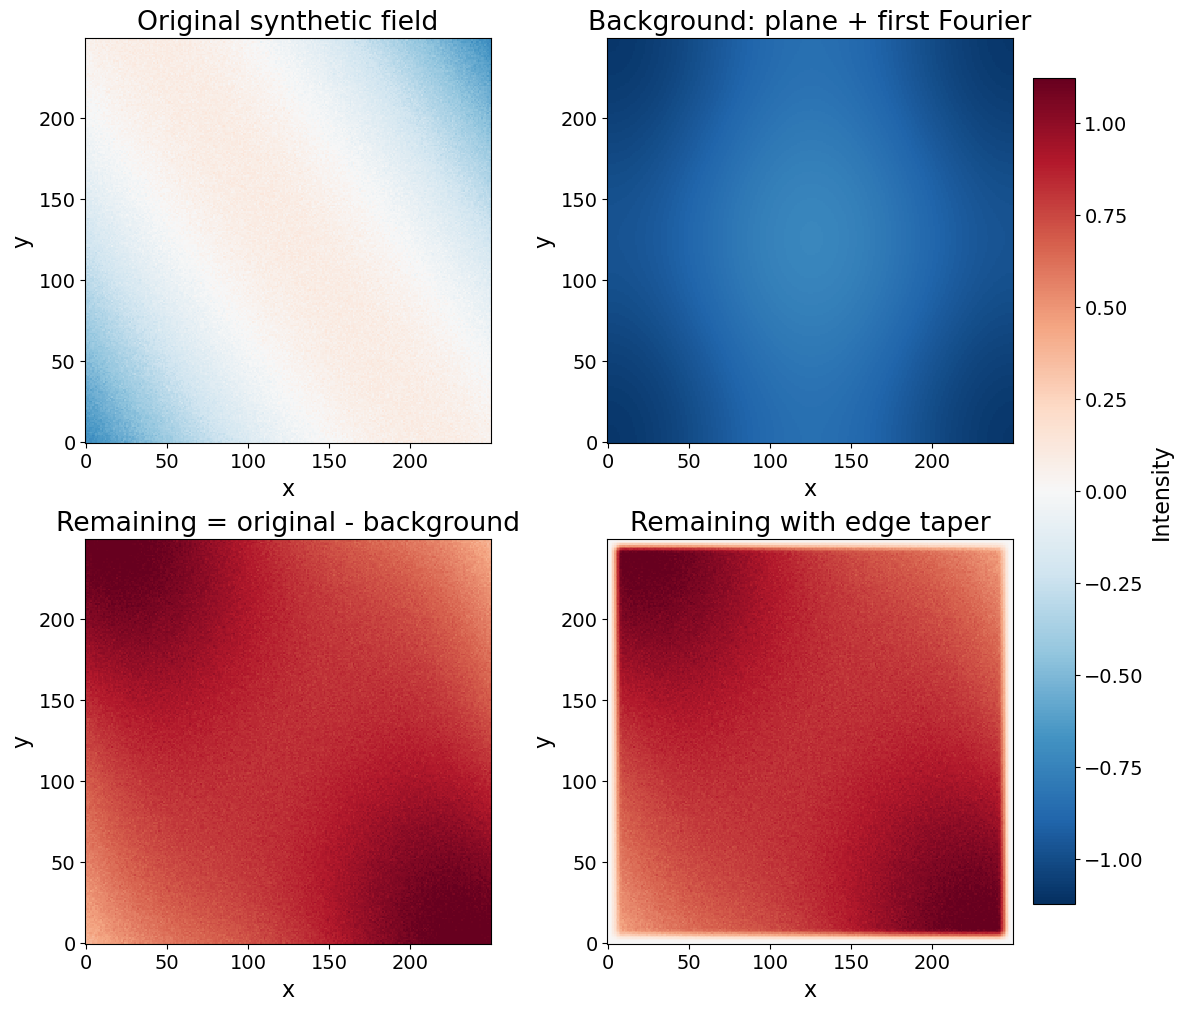

/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/juwavelet/utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|█████████████████████████████████████████████| 6/6 [00:00<00:00, 67.48it/s]
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/juwavelet/utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


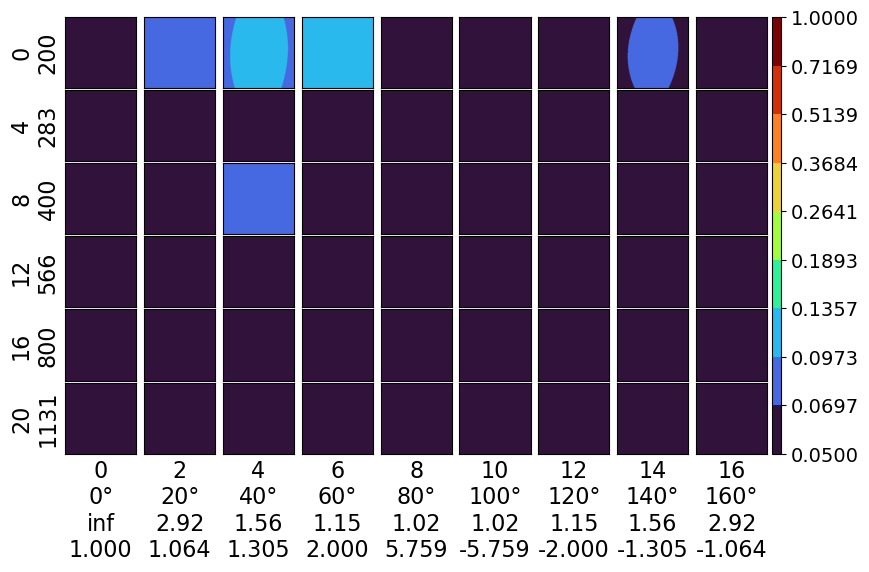

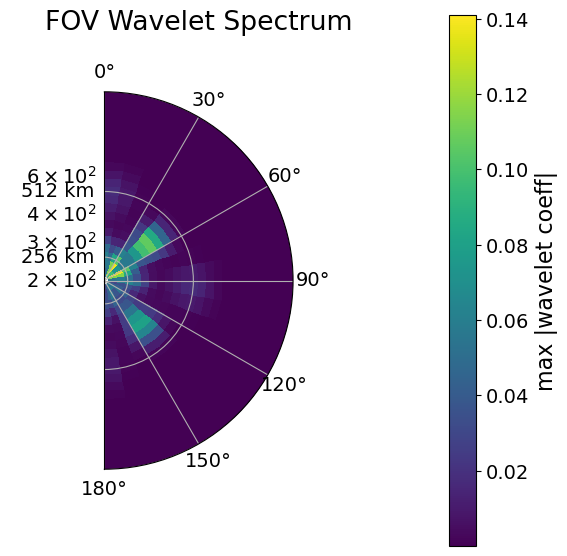


[Clusters] found: 0
[Clusters] showing: 0


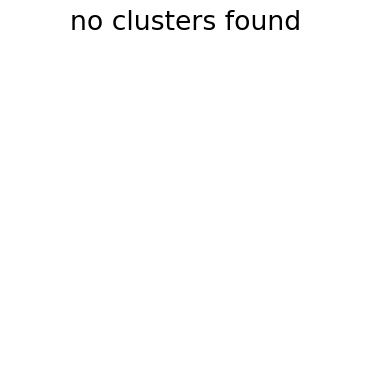

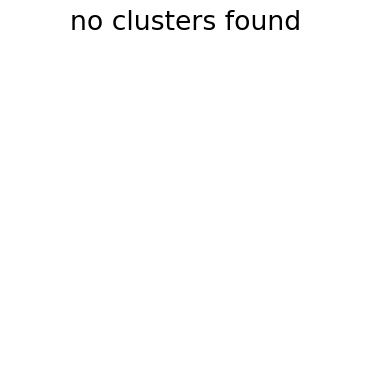

In [28]:
from __future__ import annotations
from typing import Tuple

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from scipy.ndimage import median_filter
from juwavelet import transform, utils, plot_utils


# --------------------------
# User params
# --------------------------
NX = 250
NY = 250

DX = 1
DY = 1

# No flipping. No angle conversion.
# Image-coordinate convention:
#   +x = right
#   +y = downward
#   angle is used exactly as entered
USE_CARTESIAN_COORDS = False
FLIP_DISPLAY_ANGLE = False


# --------------------------
# Synthetic wave: one long wave
# --------------------------
WAVE_X0 = NX / 2
WAVE_Y0 = NY / 2

# Envelope is bigger than the whole FOV
WAVE_SIGMA_X = 1600
WAVE_SIGMA_Y = 1600

WAVE_AMP = 1.0

# Larger than FOV: FOV is 250 km if DX = 1 km/pixel
WAVE_LAMBDA_KM = 800.0

WAVE_ANGLE_DEG = 35.0
WAVE_PHASE = 0.0

# Keep straight crests
WAVE_CURVATURE = 0.0


# Noise
NOISE_STD = 0.02
RANDOM_SEED = 1

# Optional weak background
ADD_BACKGROUND = False
BACKGROUND_AMP = 0.10

# Preprocessing
REMOVE_TREND = False
STANDARDIZE = True

APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10

APPLY_DESPIKE = False
DESPIKE_SIZE = 5
DESPIKE_K = 2.0

# Wavelet params
# Need larger scales for wavelength > FOV
S0 = 200
DJ = 1 / 8
JS = 24
JT = 18
ASPECT = 1

# Cluster identification
CLUSTER_MIN_AMP = 0.15
CLUSTER_THR = 0.1
N_CLUSTERS_SHOW = 9


matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})


# --------------------------
# Helpers
# --------------------------
def make_coordinate_grids() -> Tuple[np.ndarray, np.ndarray]:
    y, x = np.mgrid[0:NY, 0:NX]
    return x.astype(float), y.astype(float)


def make_gaussian_wave(
    x: np.ndarray,
    y: np.ndarray,
    x0: float,
    y0: float,
    sigma_x: float,
    sigma_y: float,
    amp: float,
    wavelength_km: float,
    angle_deg: float,
    phase: float = 0.0,
    curvature: float = 0.0,
) -> np.ndarray:
    theta = np.deg2rad(angle_deg)

    lambda_pix = wavelength_km / DX
    k_pix = 2.0 * np.pi / lambda_pix

    x_rel = x - x0
    y_rel = y - y0

    s = x_rel * np.cos(theta) + y_rel * np.sin(theta)
    q = -x_rel * np.sin(theta) + y_rel * np.cos(theta)

    s_curved = s + curvature * q**2

    envelope = np.exp(
        -0.5 * (
            (x_rel / sigma_x) ** 2
            + (y_rel / sigma_y) ** 2
        )
    )

    wave = amp * envelope * np.cos(k_pix * s_curved + phase)

    return wave


def make_synthetic_field() -> np.ndarray:
    rng = np.random.default_rng(RANDOM_SEED)

    x, y = make_coordinate_grids()

    wave = make_gaussian_wave(
        x=x,
        y=y,
        x0=WAVE_X0,
        y0=WAVE_Y0,
        sigma_x=WAVE_SIGMA_X,
        sigma_y=WAVE_SIGMA_Y,
        amp=WAVE_AMP,
        wavelength_km=WAVE_LAMBDA_KM,
        angle_deg=WAVE_ANGLE_DEG,
        phase=WAVE_PHASE,
        curvature=WAVE_CURVATURE,
    )

    if ADD_BACKGROUND:
        background = BACKGROUND_AMP * (
            0.6 * np.sin(2.0 * np.pi * x / NX)
            + 0.4 * np.cos(2.0 * np.pi * y / NY)
        )
    else:
        background = 0.0

    noise = rng.normal(0.0, NOISE_STD, size=(NY, NX))

    field = wave + background + noise

    return field.astype(np.float32)


def fit_plane(Z: np.ndarray) -> np.ndarray:
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]

    G = np.stack(
        [xx.ravel(), yy.ravel(), np.ones(nx * ny)],
        axis=1,
    )

    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)

    plane = coeff[0] * xx + coeff[1] * yy + coeff[2]

    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    ny, nx = Z.shape

    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg

    return bg, resid


def despike_local_sigma(
    Z: np.ndarray,
    size: int = 3,
    k: float = 5.0,
) -> np.ndarray:
    Z = np.asarray(Z, float)

    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad

    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]

    return Z_clean


def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    w = np.ones(n, dtype=float)

    if edge <= 0:
        return w

    edge = min(edge, n // 2)

    ramp = 0.5 * (
        1.0 - np.cos(np.linspace(0.0, np.pi, edge, endpoint=True))
    )

    w[:edge] = ramp
    w[-edge:] = ramp[::-1]

    return w


def apply_edge_hanning_taper(
    Z: np.ndarray,
    edge: int,
) -> np.ndarray:
    ny, nx = Z.shape

    if edge <= 0:
        return Z

    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)

    W = np.outer(wy, wx)

    return Z * W


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"

    v = float(v)

    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"

    if abs(v) >= 100:
        return f"{v:.0f}"

    return f"{v:.1f}"


def grid_for_nshow(n_show: int) -> Tuple[int, int]:
    if n_show == 9:
        return 3, 3

    if n_show == 6:
        return 2, 3

    if n_show == 3:
        return 1, 3

    return 1, max(n_show, 1)


def harmonic_wavelength_km(
    cwt: dict,
    s_idx: int,
    t_idx: int,
) -> float:
    lamx = cwt["wavelength_x"][s_idx, t_idx]
    lamy = cwt["wavelength_y"][s_idx, t_idx]

    inv2 = 0.0

    if np.isfinite(lamx) and lamx != 0:
        inv2 += (1.0 / lamx) ** 2

    if np.isfinite(lamy) and lamy != 0:
        inv2 += (1.0 / lamy) ** 2

    if inv2 == 0:
        return np.inf

    return 1.0 / np.sqrt(inv2)


# --------------------------
# Main pipeline
# --------------------------
def run_pipeline():
    raw = make_synthetic_field()

    ny, nx = raw.shape

    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)

    print(f"[Synthetic] shape: {raw.shape}")
    print(f"[Synthetic] min/max: {np.nanmin(raw):.3f} / {np.nanmax(raw):.3f}")

    print("")
    print("[Coordinate convention]")
    print("  No flipping")
    print("  No angle conversion")
    print("  +x = right")
    print("  +y = downward")
    print("  angles are used exactly as entered")

    print("")
    print("[Truth] One long wave")
    print(f"  center = ({WAVE_X0:.1f}, {WAVE_Y0:.1f}) px")
    print(f"  FOV = {NX * DX:.1f} km × {NY * DY:.1f} km")
    print(f"  wavelength = {WAVE_LAMBDA_KM:.2f} km")
    print(f"  angle = {WAVE_ANGLE_DEG:.2f} deg")
    print(f"  amplitude = {WAVE_AMP:.2f}")
    print(f"  curvature = {WAVE_CURVATURE:.4f}")

    # --------------------------
    # Show synthetic input
    # --------------------------
    fig0, ax0 = plt.subplots(figsize=(9, 6))

    im0 = ax0.pcolormesh(
        x1d,
        y1d,
        raw,
        shading="auto",
        cmap="RdBu_r",
    )

    fig0.colorbar(
        im0,
        ax=ax0,
        fraction=0.046,
        pad=0.04,
        label="Synthetic intensity",
    )

    ax0.plot(
        WAVE_X0,
        WAVE_Y0,
        "wo",
        markeredgecolor="k",
        markersize=8,
        label=f"Long wave: λ={WAVE_LAMBDA_KM:.0f} km",
    )

    ax0.set_title("Synthetic field: one wave larger than FOV")
    ax0.set_xlabel("x")
    ax0.set_ylabel("y")
    ax0.set_aspect("equal")
    ax0.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

    # --------------------------
    # Background separation
    # --------------------------
    proc0 = raw.copy()

    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)

    background = plane + fourier_bg
    remaining = proc0 - background

    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(
            remaining,
            TAPER_EDGE_PIXELS,
        )
    else:
        remaining_tapered = remaining.copy()

    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered,
            size=DESPIKE_SIZE,
            k=DESPIKE_K,
        )
    else:
        remaining_tapered_clean = remaining_tapered

    orig_c = proc0 - np.nanmedian(proc0)
    bg_c = background - np.nanmedian(proc0)
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    stacked = np.concatenate(
        [
            orig_c.ravel(),
            bg_c.ravel(),
            rem_c.ravel(),
            rem_tapered_c.ravel(),
        ]
    )

    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))

    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0

    vmin = -vmax

    fig_bg, axs_bg = plt.subplots(
        2,
        2,
        figsize=(12, 10),
        constrained_layout=True,
    )

    axes_bg_flat = axs_bg.flatten()

    imgs_bg = [
        (orig_c, "Original synthetic field"),
        (bg_c, "Background: plane + first Fourier"),
        (rem_c, "Remaining = original - background"),
        (rem_tapered_c, "Remaining with edge taper"),
    ]

    im_bg = None

    for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
        im_bg = ax.pcolormesh(
            x1d,
            y1d,
            Z,
            shading="auto",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_aspect("equal")

    cbar_bg = fig_bg.colorbar(
        im_bg,
        ax=axs_bg,
        orientation="vertical",
        fraction=0.04,
        pad=0.02,
    )

    cbar_bg.set_label("Intensity")

    plt.show()

    # --------------------------
    # Preprocess for CWT
    # --------------------------
    proc = remaining_tapered_clean.copy()

    if STANDARDIZE:
        proc = proc - np.nanmedian(proc)
        s_proc = np.nanstd(proc)

        if s_proc > 0:
            proc = proc / s_proc

    # juwavelet expects shape: nx, ny
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy,
        dx=DX,
        dy=DY,
        s0=S0,
        dj=DJ,
        js=JS,
        jt=JT,
        aspect=ASPECT,
    )

    amps, idxs, iwave = utils.identify_cluster2d(
        cwt,
        min_amp=CLUSTER_MIN_AMP,
        thr=CLUSTER_THR,
    )

    decomposition = cwt["decomposition"]
    orig_decomp = decomposition.copy()

    # --------------------------
    # CWT summary
    # --------------------------
    cmap_cwt = matplotlib.cm.turbo

    norm_cwt = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)),
        cmap_cwt.N,
    )

    fig_cwt, _ = utils.plot_decomposition2d(
        cwt,
        redux_s=4,
        redux_t=2,
        cmap=cmap_cwt,
        norm=norm_cwt,
    )

    plt.show(fig_cwt)

    # --------------------------
    # FOV wavelet spectrum
    # --------------------------
    plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")

    # --------------------------
    # Cluster plots
    # --------------------------
    bg_tapered_centered = (
        remaining_tapered_clean - np.nanmedian(remaining_tapered_clean)
    )

    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))

    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0

    bg_vmin = -bg_vmax

    n_clusters = len(amps) if amps is not None else 0
    n_show = min(N_CLUSTERS_SHOW, n_clusters) if n_clusters > 0 else 0

    print("")
    print(f"[Clusters] found: {n_clusters}")
    print(f"[Clusters] showing: {n_show}")

    number_box = {
        "boxstyle": "square",
        "lw": 0.67,
        "facecolor": "white",
        "edgecolor": "black",
    }

    nrows, ncols = grid_for_nshow(n_show)

    # --------------------------
    # Figure 1: standalone clusters
    # --------------------------
    fig1, axs1 = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 4 * nrows),
    )

    axes1_flat = np.atleast_1d(axs1).ravel()

    opts_img_cluster = {
        "cmap": "RdBu_r",
        "vmin": -0.8,
        "vmax": 0.8,
        "rasterized": True,
    }

    if n_show == 0:
        for ax in axes1_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        biggest = order[:n_show]

        for ax, kcl in zip(axes1_flat[:n_show], biggest):
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0

            rec = transform.reconstruct2d(cwt)
            rec_centered = rec.T - np.nanmedian(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]
            lam = harmonic_wavelength_km(cwt, s_idx, t_idx)

            ax.set_title(rf"$\lambda$={_fmt(lam)} km")

            ax.pcolormesh(
                x1d,
                y1d,
                rec_centered,
                shading="auto",
                **opts_img_cluster,
            )

            ax.set_aspect("equal", adjustable="box")

            decomposition_abs = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition_abs[s_idx, t_idx].argmax(),
                decomposition_abs[0, 0].shape,
            )

            ax.plot(
                x1d[max_idx[0]],
                y1d[max_idx[1]],
                "o",
                color="w",
                mec="k",
                ms=8,
            )

            print(
                f"[Clusters-only] Cluster {kcl}: "
                f"amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, "
                f"lamy={lamy:.2f}, "
                f"lam={lam:.2f}"
            )

        for ax in axes1_flat[n_show:]:
            ax.axis("off")

    for ax in axes1_flat[:max(n_show, 1)]:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    for i, ax in enumerate(axes1_flat[:n_show], start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig1.tight_layout()
    plt.show(fig1)

    # --------------------------
    # Figure 2: overlays
    # --------------------------
    fig2, axs2 = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 4 * nrows),
    )

    axes2_flat = np.atleast_1d(axs2).ravel()

    if n_show == 0:
        for ax in axes2_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        biggest = order[:n_show]

        cl_vmin, cl_vmax = -0.6, 0.6

        for ax, kcl in zip(axes2_flat[:n_show], biggest):
            ax.pcolormesh(
                x1d,
                y1d,
                bg_tapered_centered,
                shading="auto",
                cmap="gray",
                vmin=bg_vmin,
                vmax=bg_vmax,
            )

            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0

            rec = transform.reconstruct2d(cwt)
            rec_centered = rec.T - np.nanmedian(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]
            lam = harmonic_wavelength_km(cwt, s_idx, t_idx)

            ax.pcolormesh(
                x1d,
                y1d,
                rec_centered,
                shading="auto",
                cmap="RdBu_r",
                vmin=cl_vmin,
                vmax=cl_vmax,
                alpha=0.6,
            )

            ax.set_title(rf"$\lambda$={_fmt(lam)} km")
            ax.set_aspect("equal", adjustable="box")

            print(
                f"[Overlay] Cluster {kcl}: "
                f"amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, "
                f"lamy={lamy:.2f}, "
                f"lam={lam:.2f}"
            )

        for ax in axes2_flat[n_show:]:
            ax.axis("off")

    for ax in axes2_flat[:max(n_show, 1)]:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    for i, ax in enumerate(axes2_flat[:n_show], start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig2.tight_layout()
    plt.show(fig2)


if __name__ == "__main__":
    run_pipeline()

## Propagating synthetic big wave

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from pathlib import Path


# ==================================================
# Settings
# ==================================================
OUT_DIR = Path("propagating_wave_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

NX = 250
NY = 250

DX_KM = 1.0
DY_KM = 1.0

DT_SECONDS = 30
TOTAL_TIME_SECONDS = 3600*4

SPEED_MS = 150.0
SPEED_KMS = SPEED_MS / 1000.0

WAVE_LAMBDA_KM = 800.0
WAVE_ANGLE_DEG = 15.0

WAVE_AMP = 1.0

# Large envelope so the wave fills most/all of the FOV
WAVE_SIGMA_X_KM = 1200.0
WAVE_SIGMA_Y_KM = 1200.0

NOISE_STD = 0.02
RANDOM_SEED = 1

FPS = 20
DPI = 200

CMAP = "RdBu_r"


# ==================================================
# Coordinate grid
# ==================================================
x_km = np.arange(NX) * DX_KM
y_km = np.arange(NY) * DY_KM
x2d, y2d = np.meshgrid(x_km, y_km)

x0 = 0.5 * (NX - 1) * DX_KM
y0 = 0.5 * (NY - 1) * DY_KM

times_s = np.arange(0, TOTAL_TIME_SECONDS + DT_SECONDS, DT_SECONDS)
times_min = times_s / 60.0
nt = len(times_s)

theta = np.deg2rad(WAVE_ANGLE_DEG)

# Propagation direction coordinate
s_km = (x2d - x0) * np.cos(theta) + (y2d - y0) * np.sin(theta)

# Envelope
envelope = np.exp(
    -0.5 * (
        ((x2d - x0) / WAVE_SIGMA_X_KM) ** 2
        + ((y2d - y0) / WAVE_SIGMA_Y_KM) ** 2
    )
)

k = 2.0 * np.pi / WAVE_LAMBDA_KM


# ==================================================
# Create time series
# ==================================================
rng = np.random.default_rng(RANDOM_SEED)

wave_cube = np.zeros((nt, NY, NX), dtype=np.float32)

for it, t in enumerate(times_s):
    displacement_km = SPEED_KMS * t

    phase = k * (s_km - displacement_km)

    field = WAVE_AMP * envelope * np.cos(phase)
    field += rng.normal(0.0, NOISE_STD, size=field.shape)

    wave_cube[it] = field.astype(np.float32)


# Consistent color limits
vmax = np.nanpercentile(np.abs(wave_cube), 99)
vmin = -vmax


# ==================================================
# Animation
# ==================================================
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    wave_cube[0],
    origin="upper",
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    extent=[x_km.min(), x_km.max(), y_km.max(), y_km.min()],
)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Synthetic wave amplitude")

title = ax.set_title("")
ax.set_xlabel("E-W distance (km)")
ax.set_ylabel("N-S distance (km)")
ax.set_aspect("equal")


def update(frame):
    im.set_data(wave_cube[frame])
    title.set_text(
        f"Propagating Synthetic Wave | "
        f"t = {times_min[frame]:.1f} min | "
        f"speed = {SPEED_MS:.0f} m/s"
    )
    return im, title


ani = FuncAnimation(
    fig,
    update,
    frames=nt,
    interval=1000 / FPS,
    blit=False,
)

out_mp4 = OUT_DIR / "propagating_wave_animation.mp4"

writer = FFMpegWriter(fps=FPS, bitrate=3000)
ani.save(out_mp4, writer=writer, dpi=DPI)

plt.close(fig)


# ==================================================
# Keograms
# ==================================================
center_x_idx = NX // 2
center_y_idx = NY // 2

# N-S keogram: vertical slice through center x
keogram_ns = wave_cube[:, :, center_x_idx]

# E-W keogram: horizontal slice through center y
keogram_ew = wave_cube[:, center_y_idx, :]


# --------------------------
# N-S keogram
# --------------------------
fig_ns, ax_ns = plt.subplots(figsize=(9, 5))

im_ns = ax_ns.imshow(
    keogram_ns.T,
    origin="lower",
    aspect="auto",
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    extent=[
        times_min.min(),
        times_min.max(),
        y_km.min(),
        y_km.max(),
    ],
)

cbar_ns = fig_ns.colorbar(im_ns, ax=ax_ns, fraction=0.046, pad=0.04)
cbar_ns.set_label("Synthetic wave amplitude")

ax_ns.set_title("N-S Keogram")
ax_ns.set_xlabel("Time (min)")
ax_ns.set_ylabel("N-S distance (km)")

plt.tight_layout()

out_ns = OUT_DIR / "keogram_NS.png"
fig_ns.savefig(out_ns, dpi=DPI, bbox_inches="tight")
plt.close(fig_ns)


# --------------------------
# E-W keogram
# --------------------------
fig_ew, ax_ew = plt.subplots(figsize=(9, 5))

im_ew = ax_ew.imshow(
    keogram_ew.T,
    origin="lower",
    aspect="auto",
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    extent=[
        times_min.min(),
        times_min.max(),
        x_km.min(),
        x_km.max(),
    ],
)

cbar_ew = fig_ew.colorbar(im_ew, ax=ax_ew, fraction=0.046, pad=0.04)
cbar_ew.set_label("Synthetic wave amplitude")

ax_ew.set_title("E-W Keogram")
ax_ew.set_xlabel("Time (min)")
ax_ew.set_ylabel("E-W distance (km)")

plt.tight_layout()

out_ew = OUT_DIR / "keogram_EW.png"
fig_ew.savefig(out_ew, dpi=DPI, bbox_inches="tight")
plt.close(fig_ew)

np.save(OUT_DIR / "keogram_NS.npy", keogram_ns)
np.save(OUT_DIR / "keogram_EW.npy", keogram_ew)
np.save(OUT_DIR / "times_s.npy", times_s)
np.save(OUT_DIR / "x_km.npy", x_km)
np.save(OUT_DIR / "y_km.npy", y_km)

# ==================================================
# Save one final frame too
# ==================================================
fig_last, ax_last = plt.subplots(figsize=(7, 6))

im_last = ax_last.imshow(
    wave_cube[-1],
    origin="upper",
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    extent=[x_km.min(), x_km.max(), y_km.max(), y_km.min()],
)

cbar_last = fig_last.colorbar(im_last, ax=ax_last, fraction=0.046, pad=0.04)
cbar_last.set_label("Synthetic wave amplitude")

ax_last.set_title("Final Frame: Propagating Synthetic Wave")
ax_last.set_xlabel("E-W distance (km)")
ax_last.set_ylabel("N-S distance (km)")
ax_last.set_aspect("equal")

plt.tight_layout()

out_last = OUT_DIR / "final_frame.png"
fig_last.savefig(out_last, dpi=DPI, bbox_inches="tight")
plt.close(fig_last)


print("Saved:")
print(out_mp4)
print(out_ns)
print(out_ew)
print(out_last)

Saved:
propagating_wave_outputs\propagating_wave_animation.mp4
propagating_wave_outputs\keogram_NS.png
propagating_wave_outputs\keogram_EW.png
propagating_wave_outputs\final_frame.png


## 7 keograms

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from pathlib import Path
from scipy.ndimage import map_coordinates


# ==================================================
# Settings
# ==================================================
OUT_DIR = Path("propagating_wave_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

NX = 250
NY = 250

DX_KM = 1.0
DY_KM = 1.0

DT_SECONDS = 30
TOTAL_TIME_SECONDS = 3600 * 4

SPEED_MS = 150.0
SPEED_KMS = SPEED_MS / 1000.0

WAVE_LAMBDA_KM = 400.0
WAVE_ANGLE_DEG = 15.0

WAVE_AMP = 1.0

# Keep large envelope
WAVE_SIGMA_X_KM = 800.0
WAVE_SIGMA_Y_KM = 800.0

NOISE_STD = 0.02
RANDOM_SEED = 1

FPS = 20
DPI = 200

CMAP = "RdBu_r"

# Directional keograms
KEOGRAM_ANGLES_DEG = np.arange(0, 166, 15)
KEOGRAM_WIDTH_PIXELS = 3


# ==================================================
# Coordinate grid
# ==================================================
x_km = np.arange(NX) * DX_KM
y_km = np.arange(NY) * DY_KM
x2d, y2d = np.meshgrid(x_km, y_km)

x0 = 0.5 * (NX - 1) * DX_KM
y0 = 0.5 * (NY - 1) * DY_KM

times_s = np.arange(0, TOTAL_TIME_SECONDS + DT_SECONDS, DT_SECONDS)
times_min = times_s / 60.0
nt = len(times_s)

theta = np.deg2rad(WAVE_ANGLE_DEG)

k = 2.0 * np.pi / WAVE_LAMBDA_KM


# ==================================================
# Create time series
# ==================================================
rng = np.random.default_rng(RANDOM_SEED)

wave_cube = np.zeros((nt, NY, NX), dtype=np.float32)

for it, t in enumerate(times_s):
    displacement_km = SPEED_KMS * t

    # Moving wave packet center
    x_center_t = x0 + displacement_km * np.cos(theta)
    y_center_t = y0 + displacement_km * np.sin(theta)

    # Moving envelope
    envelope_t = np.exp(
        -0.5 * (
            ((x2d - x_center_t) / WAVE_SIGMA_X_KM) ** 2
            + ((y2d - y_center_t) / WAVE_SIGMA_Y_KM) ** 2
        )
    )

    # Directional coordinate measured from the original center
    s_km = (x2d - x0) * np.cos(theta) + (y2d - y0) * np.sin(theta)

    # Propagating phase
    phase = k * (s_km - displacement_km)

    field = WAVE_AMP * envelope_t * np.cos(phase)
    field += rng.normal(0.0, NOISE_STD, size=field.shape)

    wave_cube[it] = field.astype(np.float32)


vmax = np.nanpercentile(np.abs(wave_cube), 99)
vmin = -vmax


# ==================================================
# Animation
# ==================================================
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    wave_cube[0],
    origin="upper",
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    extent=[x_km.min(), x_km.max(), y_km.max(), y_km.min()],
)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Synthetic wave amplitude")

title = ax.set_title("")
ax.set_xlabel("E-W distance (km)")
ax.set_ylabel("N-S distance (km)")
ax.set_aspect("equal")


def update(frame):
    im.set_data(wave_cube[frame])
    title.set_text(
        f"Moving Synthetic Wave Packet | "
        f"t = {times_min[frame]:.1f} min | "
        f"speed = {SPEED_MS:.0f} m/s"
    )
    return im, title


ani = FuncAnimation(
    fig,
    update,
    frames=nt,
    interval=1000 / FPS,
    blit=False,
)

out_mp4 = OUT_DIR / "moving_wave_packet_animation.mp4"

writer = FFMpegWriter(fps=FPS, bitrate=3000)
ani.save(out_mp4, writer=writer, dpi=DPI)

plt.close(fig)


# ==================================================
# Save first frame with directional keogram cuts
# ==================================================
fig_first, ax_first = plt.subplots(figsize=(7, 6))

im_first = ax_first.imshow(
    wave_cube[0],
    origin="upper",
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    extent=[x_km.min(), x_km.max(), y_km.max(), y_km.min()],
)

cbar_first = fig_first.colorbar(im_first, ax=ax_first, fraction=0.046, pad=0.04)
cbar_first.set_label("Synthetic wave amplitude")

cx_km = x0
cy_km = y0
half_length_km = 0.5 * min((NX - 1) * DX_KM, (NY - 1) * DY_KM)

for angle_deg in KEOGRAM_ANGLES_DEG:
    theta_cut = np.deg2rad(angle_deg)

    dx_line = half_length_km * np.cos(theta_cut)
    dy_line = half_length_km * np.sin(theta_cut)

    x_line = [cx_km - dx_line, cx_km + dx_line]
    y_line = [cy_km - dy_line, cy_km + dy_line]

    ax_first.plot(
        x_line,
        y_line,
        linewidth=1.2,
        alpha=0.8,
        label=f"{angle_deg:.0f}°",
    )

ax_first.set_title("First Frame with Directional Keogram Cuts")
ax_first.set_xlabel("E-W distance (km)")
ax_first.set_ylabel("N-S distance (km)")
ax_first.set_aspect("equal")

ax_first.legend(
    loc="upper right",
    fontsize=7,
    ncol=2,
    framealpha=0.8,
)

plt.tight_layout()

out_first = OUT_DIR / "first_frame_with_keogram_cuts.png"
fig_first.savefig(out_first, dpi=DPI, bbox_inches="tight")
plt.close(fig_first)


# ==================================================
# Directional keogram helper
# ==================================================
def make_directional_keogram(wave_cube, angle_deg, width_pixels=3):
    """
    angle_deg:
        0 deg  = E-W slice
        90 deg = N-S slice
    """

    theta = np.deg2rad(angle_deg)

    ux = np.cos(theta)
    uy = np.sin(theta)

    px = -np.sin(theta)
    py = np.cos(theta)

    cx = (NX - 1) / 2
    cy = (NY - 1) / 2

    half_length_pix = min(NX, NY) // 2
    distances_pix = np.arange(-half_length_pix, half_length_pix + 1)

    offsets = np.arange(width_pixels) - width_pixels // 2

    keogram = np.full((nt, len(distances_pix)), np.nan, dtype=float)

    for it in range(nt):
        sampled_slices = []

        for off in offsets:
            x_sample = cx + distances_pix * ux + off * px
            y_sample = cy + distances_pix * uy + off * py

            valid = (
                (x_sample >= 0) & (x_sample <= NX - 1) &
                (y_sample >= 0) & (y_sample <= NY - 1)
            )

            values = np.full(len(distances_pix), np.nan)

            values[valid] = map_coordinates(
                wave_cube[it],
                [y_sample[valid], x_sample[valid]],
                order=1,
                mode="nearest",
            )

            sampled_slices.append(values)

        keogram[it] = np.nanmean(sampled_slices, axis=0)

    distance_km = distances_pix * DX_KM

    return keogram, distance_km


# ==================================================
# Create and save directional keograms
# ==================================================
saved_keograms = []

for angle_deg in KEOGRAM_ANGLES_DEG:
    keogram, distance_km = make_directional_keogram(
        wave_cube,
        angle_deg,
        width_pixels=KEOGRAM_WIDTH_PIXELS,
    )

    fig_k, ax_k = plt.subplots(figsize=(9, 5))

    im_k = ax_k.imshow(
        keogram.T,
        origin="lower",
        aspect="auto",
        cmap=CMAP,
        vmin=vmin,
        vmax=vmax,
        extent=[
            times_min.min(),
            times_min.max(),
            distance_km.min(),
            distance_km.max(),
        ],
    )

    cbar_k = fig_k.colorbar(im_k, ax=ax_k, fraction=0.046, pad=0.04)
    cbar_k.set_label("Synthetic wave amplitude")

    ax_k.set_title(f"Directional Keogram: {angle_deg:.0f}°")
    ax_k.set_xlabel("Time (min)")
    ax_k.set_ylabel("Distance along slice (km)")

    plt.tight_layout()

    out_png = OUT_DIR / f"keogram_angle_{angle_deg:03.0f}.png"
    out_npy = OUT_DIR / f"keogram_angle_{angle_deg:03.0f}.npy"

    fig_k.savefig(out_png, dpi=DPI, bbox_inches="tight")
    plt.close(fig_k)

    np.save(out_npy, keogram)

    saved_keograms.append(out_png)


np.save(OUT_DIR / "times_s.npy", times_s)
np.save(OUT_DIR / "x_km.npy", x_km)
np.save(OUT_DIR / "y_km.npy", y_km)
np.save(OUT_DIR / "keogram_angles_deg.npy", KEOGRAM_ANGLES_DEG)


# ==================================================
# Save final frame
# ==================================================
fig_last, ax_last = plt.subplots(figsize=(7, 6))

im_last = ax_last.imshow(
    wave_cube[-1],
    origin="upper",
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    extent=[x_km.min(), x_km.max(), y_km.max(), y_km.min()],
)

cbar_last = fig_last.colorbar(im_last, ax=ax_last, fraction=0.046, pad=0.04)
cbar_last.set_label("Synthetic wave amplitude")

ax_last.set_title("Final Frame: Moving Synthetic Wave Packet")
ax_last.set_xlabel("E-W distance (km)")
ax_last.set_ylabel("N-S distance (km)")
ax_last.set_aspect("equal")

plt.tight_layout()

out_last = OUT_DIR / "final_frame.png"
fig_last.savefig(out_last, dpi=DPI, bbox_inches="tight")
plt.close(fig_last)


# ==================================================
# Print outputs
# ==================================================
print("Saved:")
print(out_mp4)
print(out_first)
print(out_last)

print("\nDirectional keograms:")
for f in saved_keograms:
    print(f)

print(f"\nNumber of directional keograms: {len(KEOGRAM_ANGLES_DEG)}")

C:\Users\domin\AppData\Local\Temp\ipykernel_72640\379443189.py:262: RuntimeWarning: Mean of empty slice
  keogram[it] = np.nanmean(sampled_slices, axis=0)


Saved:
propagating_wave_outputs\moving_wave_packet_animation.mp4
propagating_wave_outputs\first_frame_with_keogram_cuts.png
propagating_wave_outputs\final_frame.png

Directional keograms:
propagating_wave_outputs\keogram_angle_000.png
propagating_wave_outputs\keogram_angle_015.png
propagating_wave_outputs\keogram_angle_030.png
propagating_wave_outputs\keogram_angle_045.png
propagating_wave_outputs\keogram_angle_060.png
propagating_wave_outputs\keogram_angle_075.png
propagating_wave_outputs\keogram_angle_090.png
propagating_wave_outputs\keogram_angle_105.png
propagating_wave_outputs\keogram_angle_120.png
propagating_wave_outputs\keogram_angle_135.png
propagating_wave_outputs\keogram_angle_150.png
propagating_wave_outputs\keogram_angle_165.png

Number of directional keograms: 12


## Line plots

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ==================================================
# Settings
# ==================================================
OUT_DIR = Path("propagating_wave_outputs")

KEOGRAM_FILE = OUT_DIR / "keogram_angle_015.npy"
TIMES_FILE = OUT_DIR / "times_s.npy"

DPI = 200
CMAP = "RdBu_r"


# ==================================================
# Read 15-degree keogram
# ==================================================
keogram = np.load(KEOGRAM_FILE)
times_s = np.load(TIMES_FILE)
times_min = times_s / 60.0

nt, nspace = keogram.shape

# Reconstruct distance axis used in the original script
distance_km = np.arange(-(nspace // 2), nspace // 2 + 1)

if len(distance_km) != nspace:
    distance_km = np.arange(nspace) - nspace // 2


# ==================================================
# Extract top row, bottom row, and left column
# ==================================================
# keogram shape: (time, distance)
#
# After plotting with keogram.T:
#   Top row     = maximum distance
#   Bottom row  = minimum distance
#   Left column = first time

bottom_row = keogram[:, 0]
top_row = keogram[:, -1]
left_column = keogram[0, :]


# ==================================================
# Plot keogram with selected row/column shown
# ==================================================
vmax = np.nanpercentile(np.abs(keogram), 99)
vmin = -vmax

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(
    keogram.T,
    origin="lower",
    aspect="auto",
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax,
    extent=[
        times_min.min(),
        times_min.max(),
        distance_km.min(),
        distance_km.max(),
    ],
)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Synthetic wave amplitude")

ax.axhline(
    distance_km[0],
    color="black",
    linewidth=2.0,
    label="Bottom row",
)

ax.axhline(
    distance_km[-1],
    color="red",
    linewidth=2.0,
    label="Top row",
)

ax.axvline(
    times_min[0],
    color="gray",
    linewidth=2.0,
    label="Left column",
)

ax.set_title("15° Directional Keogram with Top Row, Bottom Row, and Left Column")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Distance along slice (km)")
ax.legend(loc="upper right")

plt.tight_layout()

out_keogram_plot = OUT_DIR / "keogram_015_with_top_bottom_left.png"
fig.savefig(out_keogram_plot, dpi=DPI, bbox_inches="tight")
plt.close(fig)


# ==================================================
# Plot top row
# ==================================================
fig_t, ax_t = plt.subplots(figsize=(8, 4))

ax_t.plot(times_min, top_row, linewidth=1.5)

ax_t.set_title("Top Row of 15° Keogram")
ax_t.set_xlabel("Time (min)")
ax_t.set_ylabel("Synthetic wave amplitude")
ax_t.grid(True, alpha=0.3)

plt.tight_layout()

out_top = OUT_DIR / "keogram_015_top_row.png"
fig_t.savefig(out_top, dpi=DPI, bbox_inches="tight")
plt.close(fig_t)


# ==================================================
# Plot bottom row
# ==================================================
fig_b, ax_b = plt.subplots(figsize=(8, 4))

ax_b.plot(times_min, bottom_row, linewidth=1.5)

ax_b.set_title("Bottom Row of 15° Keogram")
ax_b.set_xlabel("Time (min)")
ax_b.set_ylabel("Synthetic wave amplitude")
ax_b.grid(True, alpha=0.3)

plt.tight_layout()

out_bottom = OUT_DIR / "keogram_015_bottom_row.png"
fig_b.savefig(out_bottom, dpi=DPI, bbox_inches="tight")
plt.close(fig_b)


# ==================================================
# Plot left column
# ==================================================
fig_l, ax_l = plt.subplots(figsize=(5, 6))

ax_l.plot(left_column, distance_km, linewidth=1.5)

ax_l.set_title("Left Column of 15° Keogram")
ax_l.set_xlabel("Synthetic wave amplitude")
ax_l.set_ylabel("Distance along slice (km)")
ax_l.grid(True, alpha=0.3)

plt.tight_layout()

out_left = OUT_DIR / "keogram_015_left_column.png"
fig_l.savefig(out_left, dpi=DPI, bbox_inches="tight")
plt.close(fig_l)


# ==================================================
# Print outputs
# ==================================================
print("Saved:")
print(out_keogram_plot)
print(out_top)
print(out_bottom)
print(out_left)

print("\nKeogram shape:")
print(f"time x distance = {keogram.shape}")

print("\nExtracted arrays:")
print(f"top_row shape = {top_row.shape}")
print(f"bottom_row shape = {bottom_row.shape}")
print(f"left_column shape = {left_column.shape}")

Saved:
propagating_wave_outputs\keogram_015_with_top_bottom_left.png
propagating_wave_outputs\keogram_015_top_row.png
propagating_wave_outputs\keogram_015_bottom_row.png
propagating_wave_outputs\keogram_015_left_column.png

Keogram shape:
time x distance = (481, 251)

Extracted arrays:
top_row shape = (481,)
bottom_row shape = (481,)
left_column shape = (251,)


## Reading Tiff file. 

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from pathlib import Path


# ==========================================================
# User settings
# ==========================================================
FOLDER = Path(r"C:\Users\domin\juwavelet\Keogram\Images for 03-25-2025")

# Frame range, inclusive
START_INDEX = 100
END_INDEX = 200

FACTOR = 0.5
FPS = 2.5
DPI = 150


# ==========================================================
# Find TIFF files
# ==========================================================
files_all = sorted(FOLDER.glob("*.tif"))

if len(files_all) == 0:
    raise FileNotFoundError(f"No TIFF files found in:\n{FOLDER}")

print(f"Found {len(files_all)} TIFF files.")

START_INDEX = max(0, START_INDEX)
END_INDEX = min(END_INDEX, len(files_all) - 1)

if START_INDEX > END_INDEX:
    raise ValueError("START_INDEX must be <= END_INDEX.")

files = files_all[START_INDEX:END_INDEX + 1]

print(f"Showing images {START_INDEX}–{END_INDEX}")
print(f"Number of images: {len(files)}")


# ==========================================================
# Read images in order
# ==========================================================
frames = []

for f in files:
    img = tiff.imread(str(f))
    frames.append(img.astype(np.float32))

data = np.stack(frames)

print("Image shape:", data.shape)


# ==========================================================
# Display limits
# ==========================================================
center = np.mean(data)
sigma = np.std(data)

vmin = center - FACTOR * sigma
vmax = center + FACTOR * sigma

print(f"\nMean  = {center:.2f}")
print(f"Sigma = {sigma:.2f}")
print(f"Range = [{vmin:.2f}, {vmax:.2f}]")


# ==========================================================
# Animation
# ==========================================================
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    np.clip(data[0], vmin, vmax),
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
    origin="upper",
)

title = ax.set_title(
    f"Image {START_INDEX}  ({1}/{len(files)})\n{files[0].name}",
    fontsize=10,
)

plt.colorbar(im, ax=ax, label="Intensity")


def update(i):
    im.set_data(np.clip(data[i], vmin, vmax))

    title.set_text(
        f"Image {START_INDEX + i}  ({i + 1}/{len(files)})\n"
        f"{files[i].name}"
    )

    return im, title


anim = FuncAnimation(
    fig,
    update,
    frames=len(files),
    interval=1000 / FPS,
    blit=False,
)

plt.close(fig)

HTML(anim.to_jshtml())


# ==========================================================
# Save MP4
# ==========================================================
out_mp4 = FOLDER / f"animation_{START_INDEX}_{END_INDEX}.mp4"

anim.save(
    str(out_mp4),
    writer="ffmpeg",
    fps=FPS,
    dpi=DPI,
)

print("\nSaved animation to:")
print(out_mp4)

Found 301 TIFF files.
Showing images 100–200
Number of images: 101
Image shape: (101, 512, 512)

Mean  = 2410.92
Sigma = 701.38
Range = [2060.23, 2761.61]

Saved animation to:
C:\Users\domin\juwavelet\Keogram\Images for 03-25-2025\animation_100_200.mp4
